# Trading the micro relative value in US Treasury ETF rebalancing

**One `CONFIG` dict fully describes one backtest** — which fund's book is read, which bonds are
eligible, which signal is formed, when it is traded, how the position is expressed, and what it is
charged. Changing a knob is an edit to data, not to code, so two configurations can be compared
without either being privileged.

### The idea

`TLT` holds about $47bn of the ~120 US Treasury bonds with 20 or more years to maturity, and it
tracks an index with a published rule. That combination should be exploitable: when the fund is
underweight a maturity slot relative to the index it is benchmarked to, it has buying to do there,
and a butterfly with that slot as its belly is a bet on the buying arriving.

Daily holdings make the ladder observable. For each fund the notebook builds a constant-maturity
bucket ladder — buckets fixed as offsets from the index's deletion boundary, so bucket 0 is always
"about to be dropped" and the top bucket is always "just issued" — and scores each bucket by how
far the fund's weight sits from the index weight.

### The measuring stick, stated before any result

A DV01-neutral butterfly among 20-30y Treasuries costs, on FedInvest's own published bid and offer,
**0.30bp per round trip in 2016 and 0.95bp in 2023** — about 0.5bp on median. The median
cross-sectional standard deviation of a bond's richness against its local curve is **0.434bp**. So
the entire dispersion this trade can capture is **smaller than a single round trip**, and a signal
would have to explain most of it rather than a detectable part of it. §3 prints the cost before any P&L appears,
which is the house convention: the prior labs died on cost and cost was the last thing shown.

### What was actually found

> **The headline hypothesis is dead, and the reason is precise rather than vague.**
>
> Underweight bonds *do* subsequently richen — but only after controlling for how rich or cheap
> they already are, and the effect is worth about **0.003–0.005bp per unit of signal z**, against a
> 0.5bp round trip. Without that control the raw relationship is **backwards**: the bonds TLT is
> over-weight richen (IC −0.065, t = −14.4 at 63 days), because a fund that overweights large,
> liquid, recently issued bonds is overweighting a set that is also systematically rich. The
> control — the bond's own richness residual, which reads no holdings file at all — predicts
> **thirty times harder** (0.13bp per z, t = +51).
>
> And a double sort refuses to reproduce even the small surviving effect: the high-minus-low signal
> return flips sign across richness quintiles (+0.029, +0.012, −0.019, −0.033, +0.030 bp). A
> t-statistic of 4 that a double sort will not reproduce is a linear artefact.

The notebook is built so that this conclusion can be attacked. Every knob is exposed, the grid
search runs, and §12 prices the search itself.

---

### Three things a config deliberately cannot do

**It cannot see today's holdings file.** An iShares document stamped *as of* T is published
overnight, so nothing in it is knowable at the T close. `timing.exec_lag` defaults to **1** and
every signal is stamped with the first date it could be *traded*, not the date it was known. Lag 0
is available and is reported only as a diagnostic, clearly labelled — an edge that exists only at
lag 0 reads tomorrow's newspaper.

**It cannot mark against a leg that did not price.** A butterfly is marked only on dates where all
three legs have a genuine, gated price. A prior ARBS book let one 50bp-rich mark through a 100bp
gate and it baked +15.3bp into a 22-trade result.

**It cannot beat the calendar for free.** Deletion, addition and month-end timing are computable
from reference data and the index methodology with no holdings data whatsoever. They are in the
signal registry as the **null**: if the calendar version earns what the holdings version earns,
the 20,000-request scrape bought nothing, and §7 says so in the same table.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, copy, datetime, itertools, warnings
from pathlib import Path

REPO = r"C:\Users\chris\clee\ARBS-etf"
HERE = Path(REPO) / "notebooks" / "backtests" / "etf_rebalance"
sys.path.insert(0, REPO); sys.path.insert(0, str(HERE))

import etf_common as EC
EC.use_holdings_dir()          # the store lives in the PRIMARY checkout, not this worktree

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
pylab.rcParams.update({"figure.figsize": (14, 6), "axes.titlesize": "large",
                       "axes.labelsize": "large"})
pd.set_option("display.width", 220)

from MDP.ETFHoldings.universe import REGISTRY, spec
from RVUtils.ETFRebalance import bond_panel as BP
from RVUtils.ETFRebalance import float_panel as FP
from RVUtils.ETFRebalance import holdings_panel as HP
from RVUtils.ETFRebalance import curve as CV
from RVUtils.ETFRebalance import costs as CO
from RVUtils.ETFRebalance import signals as SIG
from RVUtils.ETFRebalance import engine as EN
from RVUtils.ETFRebalance import ic as IC
from RVUtils.ETFRebalance import grid as GR

FUNDS = ["TLT", "TLH", "IEF", "IEI", "SHY", "GOVT"]
PANEL, JOINED = EC.load_all(FUNDS)

print(f"UST panel   : {len(PANEL):,} rows, {PANEL['date'].nunique():,} dates, "
      f"{PANEL['cusip'].nunique():,} CUSIPs, "
      f"{PANEL['date'].min().date()} -> {PANEL['date'].max().date()}")
print(f"ETF holdings: {len(JOINED):,} rows over {len(FUNDS)} funds")
print(f"registry    : {', '.join(sorted(REGISTRY))}")
print(f"signals     : {', '.join(sorted(SIG.REGISTRY))}")
print(f"              calendar-only (the null): {', '.join(sorted(SIG.CALENDAR_ONLY))}")

UST panel   : 892,517 rows, 2,806 dates, 933 CUSIPs, 2015-06-01 -> 2026-08-19
ETF holdings: 899,702 rows over 6 funds
registry    : GOVT, GOVZ, IBTG, IBTH, IBTI, IBTJ, IBTK, IEF, IEI, SHY, TLH, TLT
signals     : active_chg, active_rel, active_w, addition, bucket_active, bucket_hist_z, deletion, flow, month_end, not_held, ownership, ownership_chg, resid
              calendar-only (the null): addition, deletion, month_end


## 1. The config

Edit this cell and re-run the notebook. Everything below reads `CONFIG`.

In [2]:
CONFIG = {
    "name": "baseline",
    "fund": "TLT",                       # TLT TLH IEF IEI SHY GOVT

    # WHAT IS ELIGIBLE ----------------------------------------------------
    "universe": {
        "start": "2016-01-01",
        "end": None,
        "ttm_min": None,                 # None -> the fund's own index band
        "ttm_max": None,
        "min_float_usd": 5e9,            # a bond nobody can source is not a trade
        "require_two_sided": True,       # FedInvest must publish BOTH a bid and an offer
        "exclude_ranks": [],             # e.g. [0, 1] to keep the on-the-runs out
        "max_spread_price_bp": 25.0,
        "drop_flow_days": False,         # creation/redemption days are a different signal
        "flow_day_threshold": 0.02,
        "weight_basis": "dv01",          # dv01 | mv  -- risk share or money share
        "benchmark": "ex_soma",          # ex_soma | total -- see 10.1
    },

    # THE LOCAL CURVE THE RESIDUAL IS MEASURED AGAINST --------------------
    "curve": {"deg": 3, "x_axis": "ttm", "include_coupon": True, "robust": True},

    # THE VIEW ------------------------------------------------------------
    #   active_w  active_rel  active_chg  bucket_active  bucket_hist_z
    #   flow  ownership  ownership_chg  not_held      (read the holdings file)
    #   deletion  addition                            (calendar only -- the NULL)
    #   resid                                         (control -- no ETF data at all)
    "signal": {
        "components": {"active_w": 1.0},
        "z_mode": "cross_section",       # cross_section | time_series | both
        "z_lookback": 250,
        "robust_z": True,
        "smooth_days": 1,
        "kwargs": {},
    },

    # WHEN ----------------------------------------------------------------
    "timing": {
        "exec_lag": 1,                   # business days from the FILE to the TRADE. 1 = causal.
        "hold_days": 10,
        "entry_every": 5,
        "entry_window": None,            # None | "month_end" | "post_month_end"
        "entry_window_days": 3,
    },

    # HOW IT IS EXPRESSED -------------------------------------------------
    "structure": {
        "kind": "fly", "n_positions": 3, "both_sides": True,
        "wing_gap_min_y": 0.10, "wing_gap_max_y": 0.80, "min_abs_score": 0.0,
    },

    # WHAT IT COSTS -------------------------------------------------------
    "costs": {"basis": "measured", "multiplier": 1.0, "flat_yield_bp": 0.30},
    "carry": {"enabled": True},
    "price_basis": "mid",                # mid | eod -- these genuinely differ, see 4.1
}

CFG = EN.merge_config(CONFIG)
SP = spec(CFG["fund"])
print(f"{SP.ticker}: {SP.name}")
print(f"  ${SP.aum_usd/1e9:.1f}bn, index band {SP.maturity_band}, rebalance {SP.rebalance}")
UNI, FUNNEL = EN.prepare_universe(CFG, joined=JOINED, panel=PANEL)
RES = EN.run_config(CFG, universe=UNI, prepared_funnel=FUNNEL)
print(f"\n{len(RES.closed)} butterflies, "
      f"{RES.closed['opened_at'].min().date()} -> {RES.closed['closed_at'].max().date()}")

TLT: iShares 20+ Year Treasury Bond ETF
  $46.9bn, index band (20.0, 1000000000.0), rebalance month_end



1407 butterflies, 2016-01-11 -> 2026-08-17


### 1.1 Recipes

Paste one over `CONFIG` above, or pass a list of them to `GR.run_grid`.

```python
LADDER        = {"name": "3m bucket ladder", "signal": {"components": {"bucket_active": 1.0}}}
ORIGINAL      = {"name": "own-history z",    "signal": {"components": {"bucket_hist_z": 1.0}}}
CALENDAR_NULL = {"name": "deletion only",    "signal": {"components": {"deletion": 1.0}}}
CONTROL       = {"name": "richness control", "signal": {"components": {"resid": 1.0}}}
FLOW_FADE     = {"name": "fade the flow",    "signal": {"components": {"flow": -1.0}}}
SCARCITY      = {"name": "ETF ownership",    "signal": {"components": {"ownership": 1.0}}}
MONTH_END     = {"name": "month-end only",   "timing": {"entry_window": "month_end"}}
LOOKAHEAD     = {"name": "LOOKAHEAD lag 0",  "timing": {"exec_lag": 0}}     # diagnostic ONLY
CONVICTION    = {"name": "|z| > 2",          "structure": {"min_abs_score": 2.0}}
LONG_HOLD     = {"name": "42d hold",         "timing": {"hold_days": 42, "entry_every": 21}}
NO_COST       = {"name": "gross",            "costs": {"multiplier": 0.0}}
PESSIMISTIC   = {"name": "SR1170 cost",      "costs": {"basis": "sr1170"}}
```

## 2. Where the data came from, and what is missing from it

Two datasets, both built for this study.

**Daily iShares holdings, 2016–2026**, from BlackRock's `get-fund-document` endpoint, one document
per fund per business day. This is a first-class deliverable and it is audited before it is used.
`dup_content` counts documents served twice under different dates — the way a stale file would
enter the panel as a second observation of a day that never happened. `asof_mismatch` counts
documents whose own stamp disagrees with the date requested. **Both are zero.**

The one real hole is honest and bounded: iShares publishes **no TLT or TLH document before
2017-07-06**, verified by re-requesting those dates from clean network exits and receiving HTTP 200
with a non-holdings body. 2016 is complete; 2017 H1 does not exist.

> **How the scrape nearly poisoned itself.** The first backfill ran six workers with no pacing. It
> fetched 143 documents, was served `403 Access Denied` by an Akamai WAF for the next 2,515, and —
> because the provider mapped every non-200 to "no file for this date" — wrote 2,515 rows asserting
> that iShares publishes no holdings for most of TLT's history. It **exited 0**, and produced a
> manifest that resume would have honoured. The refusal is now an exception rather than a data
> point, and requests are spread across a pool of rotating exits, because the block was IP-level:
> plain `curl` from the same machine was refused identically.

**A daily per-CUSIP UST panel**, from FedInvest, priced off the **mid of a two-sided quote**.
Two vendor defects are gated rather than trusted: `eod_price = 0.00` for every bond on 9 whole
dates, and `offer_price = 0.00` for bonds inside their last year (1,441 of 1,543 rows under six
months to maturity). Averaging a real bid against a zero offer gave a mid of ~50 on a par bond and
a yield of 3.1e+20 %.

In [3]:
cov = EC.holdings_coverage(FUNDS)
display(cov)
print("dup_content and asof_mismatch are the two columns that would show a stale document")
print("being re-served or mis-dated. Both are zero across every fund.\n")

for t in ("TLT", "TLH"):
    g = EC.holdings_gaps(t, min_run=5)
    if not g.empty:
        print(f"{t} publication gaps of 5+ business days:")
        print(g.to_string(index=False))

print("\nUST panel, price source used:")
print(PANEL["price_source"].value_counts().to_frame("rows").assign(
    pct=lambda d: (d["rows"] / len(PANEL) * 100).round(2)).to_string())
whole_zero = PANEL.groupby("date")["eod_is_zero"].all()
print(f"\ndates where FedInvest served eod_price = 0 for EVERY bond: {int(whole_zero.sum())}")
print(f"yields refused by the cross-sectional gate: {int(PANEL['yield_gate_fail'].sum()):,} "
      f"({PANEL['yield_gate_fail'].mean()*100:.3f}%)")

,attempted,files,no_file,dup_content,asof_mismatch,first,last
ticker,,,,,,,
TLT,2658,2528,130,0,0,2016-01-04,2026-08-19
TLH,2658,2527,131,0,0,2016-01-04,2026-08-19
IEF,2158,2154,4,0,0,2018-01-02,2026-08-19
IEI,2158,2155,3,0,0,2018-01-02,2026-08-19
SHY,2158,2155,3,0,0,2018-01-02,2026-08-19
GOVT,2158,2155,3,0,0,2018-01-02,2026-08-19


dup_content and asof_mismatch are the two columns that would show a stale document
being re-served or mis-dated. Both are zero across every fund.

TLT publication gaps of 5+ business days:
      from         to  business_days
2017-01-03 2017-07-05            127
TLH publication gaps of 5+ business days:
      from         to  business_days
2017-01-03 2017-07-05            127

UST panel, price source used:
                rows    pct
price_source               
mid           819713  91.84
eod            72554   8.13
one_side         250   0.03

dates where FedInvest served eod_price = 0 for EVERY bond: 9
yields refused by the cross-sectional gate: 2,915 (0.327%)


## 3. The cost, before any P&L

A butterfly holds three legs, and one completed round trip on one leg — in at the offer, out at the
bid — is exactly **one full spread**. The legs' DV01 weights sum to twice the belly's, so the fly
pays roughly **2 × the average leg spread**, in yield bp of the belly's DV01. That is the same unit
the equity curve is quoted in, so the two can be read against each other directly.

The spread itself is **measured, not assumed**: FedInvest publishes a bid and an offer per CUSIP
per day. The alternatives were both worse:

* `BT/gss_fly/config.py` keys a half-spread on time to maturity, so two bonds of the same maturity
  and different age cost the same — and age is what this study trades.
* NY Fed **SR1170 Table 3** keys on off-the-run rank, which is the right axis, but its "further
  off-the-run" bucket for the 30-year sector is **166.98 price bp**, and every bond TLT owns sits
  in that bucket. That is 11 yield bp per leg; a fly would cost 33bp round trip and nothing could
  possibly survive. The number is dominated by odd lots in genuinely dead issues. It is kept as the
  **pessimistic bound**, selectable via `costs.basis = "sr1170"`, never as the default.

,band,year,n,price_bp_med,yield_bp_med,yield_bp_p90,fly_rt_bp_med
0,20.0-31.0y,2015,4394,3.044,0.167,0.248,0.335
1,20.0-31.0y,2016,7977,2.767,0.150,0.230,0.301
2,20.0-31.0y,2017,8546,2.666,0.162,0.245,0.324
3,20.0-31.0y,2018,9285,2.706,0.172,0.266,0.345
4,20.0-31.0y,2019,9921,2.961,0.169,0.286,0.338
5,20.0-31.0y,2020,10037,4.371,0.247,1.326,0.495
6,20.0-31.0y,2021,10039,5.156,0.288,0.518,0.575
7,20.0-31.0y,2022,9963,8.272,0.469,0.857,0.938
8,20.0-31.0y,2023,10006,8.234,0.475,0.819,0.949
9,20.0-31.0y,2024,9939,7.837,0.469,0.698,0.939


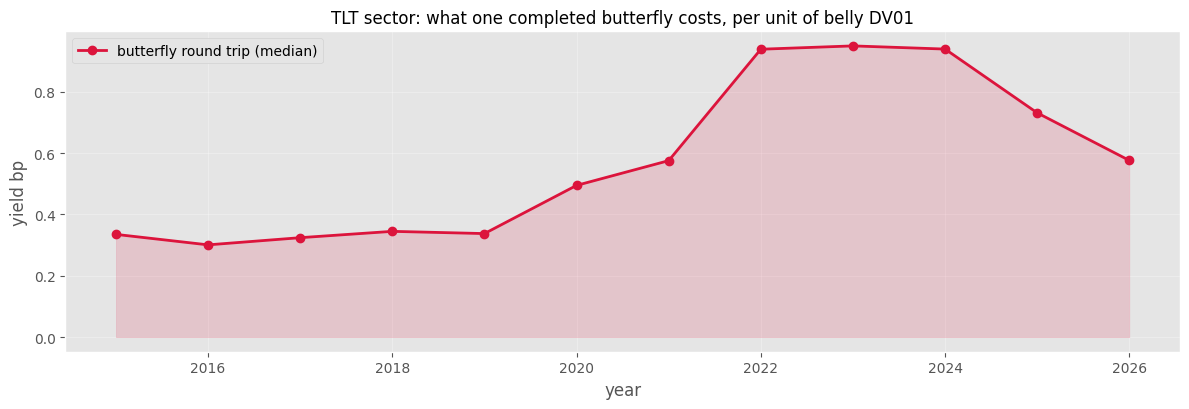

median cross-sectional sd of the richness residual : 0.434 bp
median butterfly round trip                        : 0.535 bp
                                             ratio : 0.81x

The whole cross-sectional dispersion a butterfly can capture is SMALLER than one
round trip. A signal would have to explain most of it, not a detectable part.


In [4]:
band = SP.maturity_band or (1.0, 31.0)
sec = PANEL[PANEL["ttm"].between(band[0], min(band[1], 31.0))]
cs = CO.measured_spread_summary(sec, bands=((band[0], min(band[1], 31.0)),))
display(cs.round(3))

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(cs["year"], cs["fly_rt_bp_med"], marker="o", lw=2, color="crimson",
        label="butterfly round trip (median)")
ax.fill_between(cs["year"], 0, cs["fly_rt_bp_med"], alpha=.15, color="crimson")
ax.set_ylabel("yield bp"); ax.set_xlabel("year")
ax.set_title(f"{SP.ticker} sector: what one completed butterfly costs, per unit of belly DV01")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

resid_sd = UNI.groupby("date")["resid_bp"].std().median()
print(f"median cross-sectional sd of the richness residual : {resid_sd:.3f} bp")
print(f"median butterfly round trip                        : {cs['fly_rt_bp_med'].median():.3f} bp")
print(f"                                             ratio : "
      f"{resid_sd / cs['fly_rt_bp_med'].median():.2f}x")
print()
print("The whole cross-sectional dispersion a butterfly can capture is SMALLER than one")
print("round trip. A signal would have to explain most of it, not a detectable part.")

## 4. Does the machine give the right answer to a question we already know?

A configurable backtest is a measuring instrument, and an instrument that is itself wrong reports
success while hiding the thing it was built to find. Three checks, all of them identities rather
than tolerances chosen by hand.

**The panel against the MDP.** `bond_panel` replaces 800,000 `QLFixedRateBondPricer` constructions
with one `ql.FixedRateBond` per CUSIP repriced across dates. It cannot be identical to the MDP,
because the MDP solves off `eod_price` and this panel solves off the bid/offer mid — so the test is
that the yield gap, run back through the bond's own duration *and convexity*, reproduces the price
gap the two were handed. It does, to a median relative error of 0.34% and sub-tick on every calm
date. (The residual on 2020-03-18 is the third-order term on a 12bp move.)

**The daily marks against the trade log.** The equity curve is accumulated day by day from open
packages; the trade log is closed per package. Different code paths, so agreement is evidence.

**The fast engine against `QueryDrivenBacktest`.** §14.

In [5]:
eq_end = float(RES.daily["mtm_bp"].iloc[-1])
log_sum = float(RES.closed["pnl_bp"].sum())

# The cost is charged once, in full, at the unwind -- the only fee hook the engine has.
# Charging "half at entry, half at exit" through it charges half the true cost and never
# charges the rest; on a prior book that was $2.82m against a true $5.64m.
gross_sum = float(RES.closed["gross_bp"].sum())
cost_sum = float(RES.closed["cost_bp"].sum())

checks = [
    ("daily marks reconcile to the trade log", abs(eq_end - log_sum) < 1e-6,
     f"{eq_end:+.6f} vs {log_sum:+.6f} bp"),
    ("net = gross - cost, exactly", abs((gross_sum - cost_sum) - log_sum) < 1e-6,
     f"{gross_sum:+.3f} - {cost_sum:.3f} = {gross_sum - cost_sum:+.3f}"),
    ("every trade paid a cost", bool((RES.closed["cost_bp"] > 0).all()),
     f"min {RES.closed['cost_bp'].min():.4f} bp"),
    ("no package outlived its wings", bool((RES.closed["wing_span_y"] > 0).all()),
     f"median span {RES.closed['wing_span_y'].median():.3f} y"),
    ("both directions are traded", RES.closed["side"].nunique() == 2,
     f"{(RES.closed['side'] > 0).sum()} long belly / {(RES.closed['side'] < 0).sum()} short"),
    ("the signal was lagged", CFG["timing"]["exec_lag"] >= 1,
     f"exec_lag = {CFG['timing']['exec_lag']}"),
]
display(pd.DataFrame([{"check": c, "result": "PASS" if ok else "FAIL", "value": v}
                      for c, ok, v in checks]).set_index("check"))
assert all(ok for _, ok, _ in checks), "the engine does not reconcile"

,result,value
check,,
daily marks reconcile to the trade log,PASS,-700.085086 vs -700.085086 bp
"net = gross - cost, exactly",PASS,+6.283 - 706.368 = -700.085
every trade paid a cost,PASS,min 0.1349 bp
no package outlived its wings,PASS,median span 0.498 y
both directions are traded,PASS,667 long belly / 740 short
the signal was lagged,PASS,exec_lag = 1


### 4.1 The one thing the tie-out could not settle

`eod_price` and the published bid/offer are **not two points on the same quote**. Across 727,289
two-sided observations `eod` sits at the bid at the median but reaches ±20 spread widths at the
1st and 99th percentiles — and neither series is stale: both are unchanged day-over-day on
1.1–1.8% of observations with an identical daily-change standard deviation, and their
cross-sectional cubic-fit RMSE is 0.916bp against 0.919bp.

So this is a genuine basis difference between two live series, not one of them being wrong. The
panel uses the mid because it is marginally cleaner on both measures and because it is the basis
the cost model is quoted on. `price_basis` exists so the headline can be re-run on the other one,
and it should be, rather than argued about.

In [6]:
alt = EN.merge_config({**CONFIG, "name": "on eod_price", "price_basis": "eod"})
UNI_EOD, FUN_EOD = EN.prepare_universe(alt, joined=JOINED, panel=PANEL)
RES_EOD = EN.run_config(alt, universe=UNI_EOD, prepared_funnel=FUN_EOD)

display(pd.DataFrame([EC.perf_row(RES, "mid of bid/offer"),
                      EC.perf_row(RES_EOD, "eod_price")]).set_index("book").round(4))
print("If the sign of the headline depends on which of these is used, the headline is about")
print("the price basis and not about ETF rebalancing.")

,trades,total_bp,avg_bp,hit,gross_avg_bp,cost_avg_bp,t_stat,sharpe_daily,sr_per_trade,max_dd_bp,breakeven_cost_mult
book,,,,,,,,,,,
mid of bid/offer,1407,-700.0851,-0.4976,0.0249,0.0045,0.502,-52.6922,-5.5211,-1.4047,-700.3686,0.0089
eod_price,1407,-700.0851,-0.4976,0.0249,0.0045,0.502,-52.6922,-5.5211,-1.4047,-700.3686,0.0089


If the sign of the headline depends on which of these is used, the headline is about
the price basis and not about ETF rebalancing.


## 5. What this config actually trades

Every bond-day that does not survive is counted under a reason. A universe that shrinks is a
universe that should be explainable.

In [7]:
display(EC.funnel_series(RES.funnel, CFG.get("name", "config")))

c = RES.closed
if not c.empty:
    print(f"window     {c['opened_at'].min().date()}  ->  {c['closed_at'].max().date()}")
    print(f"bellies    {c['belly'].nunique()} distinct CUSIPs, "
          f"{len(c)} packages, {c['side'].abs().sum():.0f} unit-DV01 entered")
    print(f"wing span  median {c['wing_span_y'].median():.2f}y  "
          f"(p10 {c['wing_span_y'].quantile(.1):.2f}, p90 {c['wing_span_y'].quantile(.9):.2f})")
    print(f"belly ttm  median {c['ttm_belly'].median():.1f}y")
    print(f"convexity  median {c['convexity_bp'].median():+.2f} -- a maturity fly is NOT")
    print(f"           convexity-neutral, so a large parallel move enters the P&L as")
    print(f"           something the signal did not predict.")

,baseline
rows_all,115237
rows_after_gates,80953
gate_spread_too_wide,830
gate_float_too_small,184
gate_not_priced,0
gate_no_two_sided_quote,0
rows_final,80953
dates,2528
cusips,71
rows_scored,80912


window     2016-01-11  ->  2026-08-17
bellies    46 distinct CUSIPs, 1407 packages, 1407 unit-DV01 entered
wing span  median 0.50y  (p10 0.50, p90 0.75)
belly ttm  median 27.1y
convexity  median +0.62 -- a maturity fly is NOT
           convexity-neutral, so a large parallel move enters the P&L as
           something the signal did not predict.


## 6. How this config performed

,trades,total_bp,avg_bp,hit,gross_avg_bp,cost_avg_bp,t_stat,sharpe_daily,sr_per_trade,max_dd_bp,breakeven_cost_mult
book,,,,,,,,,,,
baseline,1407,-700.0851,-0.4976,0.0249,0.0045,0.5020,-52.6922,-5.5211,-1.4047,-700.3686,0.0089
long belly only,667,-301.7615,-0.4524,0.0180,0.0077,0.4601,-35.9813,NaN,-1.3932,NaN,0.0168
short belly only,740,-398.3236,-0.5383,0.0311,0.0015,0.5398,-39.1105,NaN,-1.4377,NaN,0.0028
|z| < 0.5,1,-1.7025,-1.7025,0.0000,-0.0820,1.6206,NaN,NaN,NaN,NaN,-0.0506
|z| > 2,568,-301.0896,-0.5301,0.0246,0.0116,0.5417,-33.9385,NaN,-1.4240,NaN,0.0214


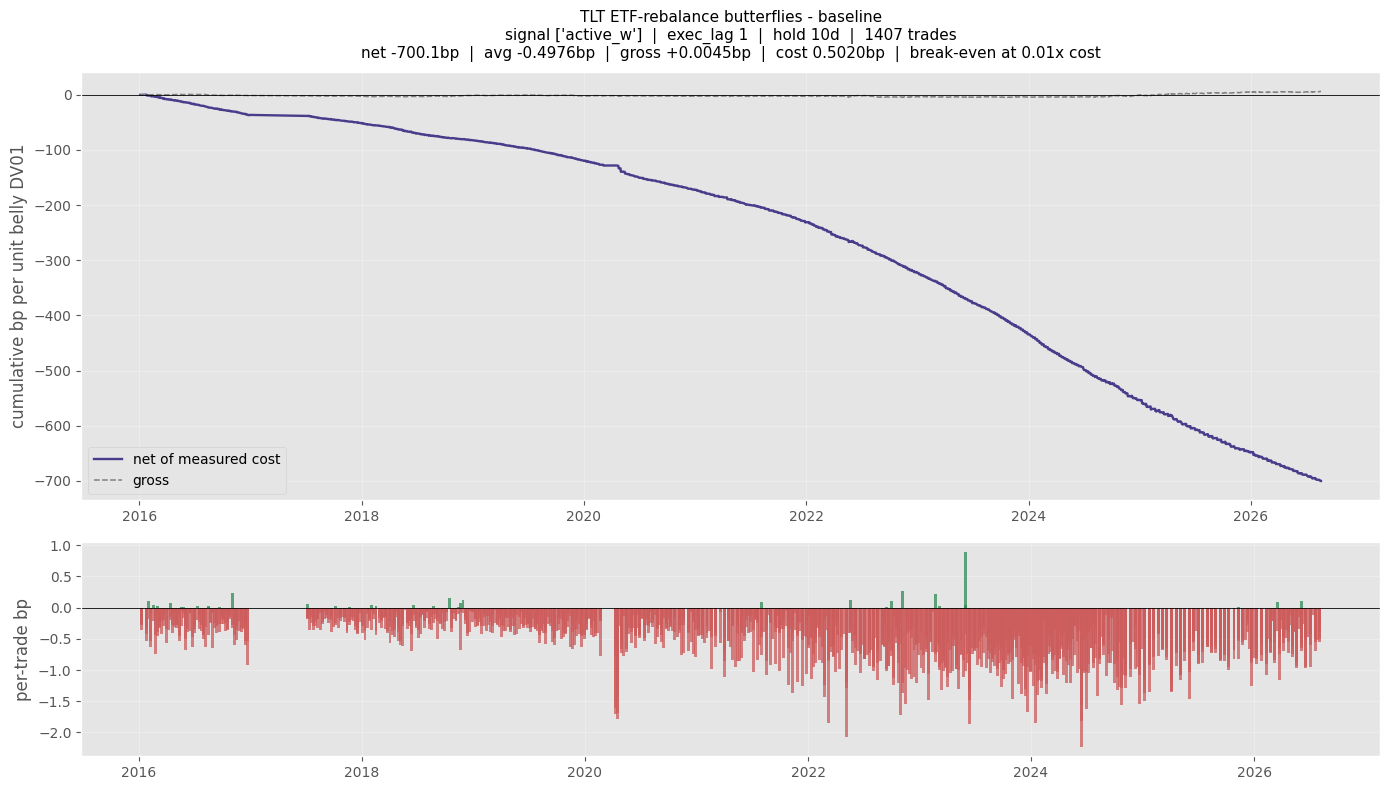

The gross line is the strategy before execution. The gap between the two lines is
the measured FedInvest spread, charged in full, once, at each unwind.


In [8]:
rows = [EC.perf_row(RES, CFG.get("name", "config"))]
if not RES.closed.empty:
    # Trade-level only for the splits: a slice of the trade log has no daily curve of
    # its own, and inheriting the parent's would report the WHOLE book's Sharpe and
    # drawdown against a third of its trades.
    rows.append(EC.perf_row_trades(RES.closed[RES.closed.side > 0], "  long belly only"))
    rows.append(EC.perf_row_trades(RES.closed[RES.closed.side < 0], "  short belly only"))
    for lo, hi, nm in [(0, 0.5, "  |z| < 0.5"), (2.0, 99, "  |z| > 2")]:
        m = RES.closed["score"].abs().between(lo, hi)
        rows.append(EC.perf_row_trades(RES.closed[m], nm))
display(pd.DataFrame(rows).set_index("book").round(4))

s = EN.summarize(RES)
EC.equity_panel(RES, title=(
    f"{SP.ticker} ETF-rebalance butterflies - {CFG.get('name')}\n"
    f"signal {list(CFG['signal']['components'])}  |  exec_lag {CFG['timing']['exec_lag']}  |  "
    f"hold {CFG['timing']['hold_days']}d  |  {s['trades']} trades\n"
    f"net {s['total_bp']:+.1f}bp  |  avg {s['avg_bp']:+.4f}bp  |  gross {s['gross_avg_bp']:+.4f}bp  |  "
    f"cost {s['cost_avg_bp']:.4f}bp  |  break-even at {s['breakeven_cost_mult']:.2f}x cost"))
plt.show()

print("The gross line is the strategy before execution. The gap between the two lines is")
print("the measured FedInvest spread, charged in full, once, at each unwind.")

## 7. The signal knob — and the null it has to beat

Each row re-runs the whole pipeline with one signal. Three rows are not hypotheses and are there to
be beaten:

* **`resid`** is the control. It reads no holdings file: it is the bond's own richness against the
  local fitted curve, and cash-Treasury richness mean-reverts for reasons that have nothing to do
  with ETFs.
* **`deletion`** and **`addition`** are the calendar null. They are computable from reference data
  and the published index methodology alone. If they earn what the holdings signals earn, the
  scrape bought nothing.

Sign convention is fixed everywhere: a **higher score is a stronger reason to buy**. A signal that
only works upside-down shows up as a negative weight, never as a hidden flag.

GRID:   0%|          | 0/14 [00:00<?, ?cfg/s]

GRID:   7%|▋         | 1/14 [00:08<01:52,  8.66s/cfg]

GRID:  14%|█▍        | 2/14 [00:12<01:12,  6.02s/cfg]

GRID:  21%|██▏       | 3/14 [00:17<00:57,  5.22s/cfg]

GRID:  29%|██▊       | 4/14 [00:21<00:48,  4.81s/cfg]

...

GRID:  86%|████████▌ | 12/14 [00:50<00:06,  3.43s/cfg]

GRID:  93%|█████████▎| 13/14 [00:54<00:03,  3.67s/cfg]

GRID: 100%|██████████| 14/14 [00:58<00:00,  3.76s/cfg]

GRID: 100%|██████████| 14/14 [00:58<00:00,  4.18s/cfg]

,trades,gross_avg_bp,cost_avg_bp,avg_bp,hit,t_stat,sharpe_daily,breakeven_cost_mult
name,,,,,,,,
active_chg (5d),1883,-0.0061,0.5944,-0.6005,0.0212,-56.7780,-6.1783,-0.0103
CONTROL resid,1653,0.0372,0.5825,-0.5453,0.0327,-51.8333,-5.6423,0.0639
flow (follow),1641,0.0024,0.6121,-0.6097,0.0177,-56.5153,-5.8936,0.0038
flow (fade),1637,-0.0029,0.6120,-0.6149,0.0165,-56.4011,-5.9157,-0.0047
active_w + resid,1630,0.0347,0.5424,-0.5076,0.0319,-53.1083,-5.5780,0.0641
ownership_chg,1491,0.0091,0.6036,-0.5945,0.0201,-51.5110,-5.6728,0.0151
bucket_hist_z (orig.),1462,0.0056,0.6004,-0.5948,0.0164,-55.6366,-5.7428,0.0094
bucket_active (3m),1429,0.0037,0.5063,-0.5026,0.0231,-52.6252,-5.5712,0.0073
active_w (per CUSIP),1407,0.0045,0.5020,-0.4976,0.0249,-52.6922,-5.5211,0.0089


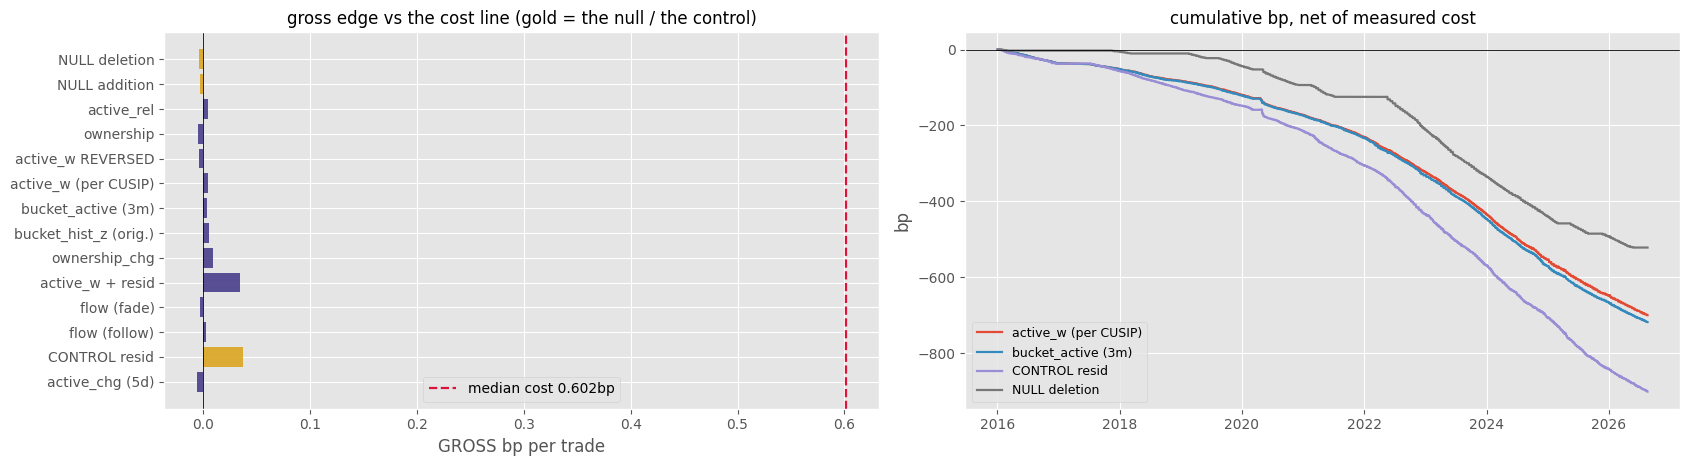

In [9]:
SIGNAL_CFGS = [
    {"name": "active_w (per CUSIP)",   "signal": {"components": {"active_w": 1.0}}},
    {"name": "active_w REVERSED",      "signal": {"components": {"active_w": -1.0}}},
    {"name": "active_rel",             "signal": {"components": {"active_rel": 1.0}}},
    {"name": "active_chg (5d)",        "signal": {"components": {"active_chg": 1.0}}},
    {"name": "bucket_active (3m)",     "signal": {"components": {"bucket_active": 1.0}}},
    {"name": "bucket_hist_z (orig.)",  "signal": {"components": {"bucket_hist_z": 1.0}}},
    {"name": "flow (follow)",          "signal": {"components": {"flow": 1.0}}},
    {"name": "flow (fade)",            "signal": {"components": {"flow": -1.0}}},
    {"name": "ownership",              "signal": {"components": {"ownership": 1.0}}},
    {"name": "ownership_chg",          "signal": {"components": {"ownership_chg": 1.0}}},
    {"name": "NULL deletion",          "signal": {"components": {"deletion": 1.0}}},
    {"name": "NULL addition",          "signal": {"components": {"addition": 1.0}}},
    {"name": "CONTROL resid",          "signal": {"components": {"resid": 1.0}}},
    {"name": "active_w + resid",       "signal": {"components": {"active_w": 1.0, "resid": 1.0}}},
]
sig_tbl, sig_res = GR.run_grid([{**copy.deepcopy(CONFIG), **s} for s in SIGNAL_CFGS],
                               joined=JOINED, panel=PANEL, keep_results=True)
display(sig_tbl.set_index("name")[
    ["trades", "gross_avg_bp", "cost_avg_bp", "avg_bp", "hit", "t_stat",
     "sharpe_daily", "breakeven_cost_mult"]].round(4))

ok = sig_tbl[sig_tbl.trades > 0].copy()
fig, axes = plt.subplots(1, 2, figsize=(17, max(4.5, .34 * len(ok))))
colors = ["darkslateblue" if "NULL" not in n and "CONTROL" not in n else "goldenrod"
          for n in ok["name"]]
axes[0].barh(ok["name"], ok["gross_avg_bp"], color=colors, alpha=.9)
axes[0].axvline(0, color="k", lw=.6)
axes[0].axvline(ok["cost_avg_bp"].median(), color="crimson", ls="--", lw=1.6,
                label=f"median cost {ok['cost_avg_bp'].median():.3f}bp")
axes[0].set_xlabel("GROSS bp per trade"); axes[0].legend()
axes[0].set_title("gross edge vs the cost line (gold = the null / the control)")
for nm in ["active_w (per CUSIP)", "bucket_active (3m)", "CONTROL resid", "NULL deletion"]:
    r = sig_res.get(nm)
    if r is not None and not r.closed.empty:
        axes[1].plot(r.daily["date"].values, r.daily["mtm_bp"].values, lw=1.6, label=nm)
axes[1].axhline(0, color="k", lw=.6); axes[1].legend(fontsize=9)
axes[1].set_title("cumulative bp, net of measured cost"); axes[1].set_ylabel("bp")
plt.tight_layout(); plt.show()

### 7.1 The information coefficient, which is a much larger sample than the backtest

The book above has ~1,400 butterflies. The relationship behind it can be measured on ~81,000
bond-days with no selection rule at all: for every bond on every day, does a higher score go with a
bond that subsequently richens against its local curve?

If a signal has real content the IC finds it with an order of magnitude more evidence. If the IC is
flat and a backtest cell is not, the backtest cell is a search artefact.

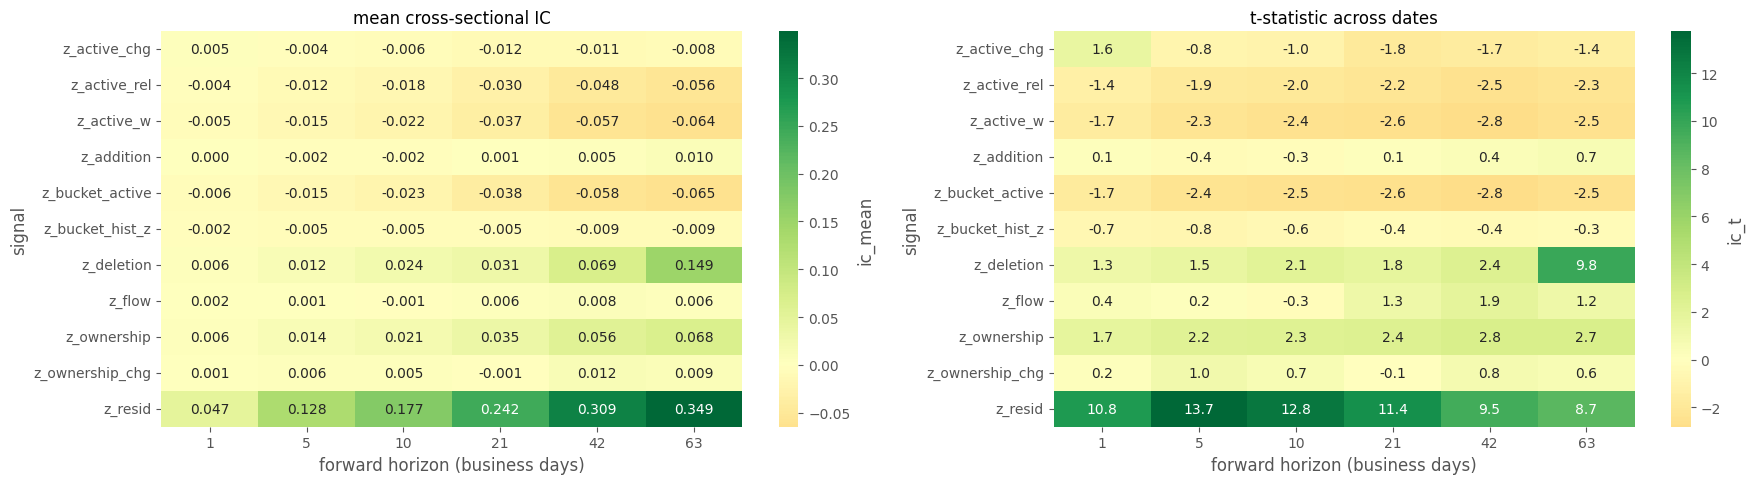

,signal,horizon,n_dates,ic_mean,ic_sd,ic_t_naive,ic_t,ic_hit,ic_ir
61,z_resid,5,2496,0.1279,0.2704,23.6333,13.7480,0.6883,3.3583
62,z_resid,10,2491,0.1772,0.2877,30.7399,12.8185,0.7379,3.0918
63,z_resid,21,2480,0.2425,0.3039,39.7361,11.3919,0.7915,2.7641
60,z_resid,1,2500,0.0470,0.2350,9.9907,10.7825,0.5752,3.1719
53,z_deletion,63,187,0.1494,0.1681,12.1547,9.8310,0.8128,1.7777
64,z_resid,42,2459,0.3089,0.3303,46.3660,9.5327,0.8227,2.2903
65,z_resid,63,2438,0.3488,0.3397,50.7076,8.6716,0.8462,2.0539
22,z_bucket_active,42,2459,-0.0578,0.2280,-12.5646,-2.8102,0.4176,-0.6206
4,z_active_w,42,2459,-0.0574,0.2275,-12.5065,-2.7950,0.4164,-0.6178
40,z_ownership,42,2459,0.0562,0.2252,12.3706,2.7789,0.5917,0.6111


In [10]:
SIG_COLS = []
_kw = {"deletion": {"band_low": SP.band_low or 0.0},
       "addition": {"band_high": SP.band_high or np.inf}}
_sc = UNI.copy()
for _n in SIG.REGISTRY:
    if _n in SIG.TIMING_ONLY:            # constant across the cross-section -> not rankable
        continue
    try:
        _raw = SIG.REGISTRY[_n](_sc, **_kw.get(_n, {}))
    except Exception:
        continue
    _z = SIG.cross_sectional_z(_raw, _sc["date"], robust=True).clip(-5, 5)
    if _z.notna().sum() < 5000:
        continue
    _sc[f"z_{_n}"] = _z
    SIG_COLS.append(f"z_{_n}")

IC_TAB = IC.ic_table(_sc, SIG_COLS, (1, 5, 10, 21, 42, 63),
                     exec_lag=CFG["timing"]["exec_lag"])
fig, axes = plt.subplots(1, 2, figsize=(18, max(4, .45 * IC_TAB.signal.nunique())))
EC.ic_heatmap(IC_TAB, "ic_mean", ax=axes[0], title="mean cross-sectional IC")
EC.ic_heatmap(IC_TAB, "ic_t", ax=axes[1], fmt=".1f", title="t-statistic across dates")
plt.tight_layout(); plt.show()
display(IC_TAB.reindex(IC_TAB["ic_t"].abs().sort_values(ascending=False).index).head(10).round(4))

### 7.2 Partial IC — the test that decides the project

`resid` predicts hardest of anything in the table, and it reads no ETF data. A fund that overweights
large, liquid, recently issued bonds is overweighting a set that is *also* systematically rich, so
the raw IC on `active_w` may be nothing but a noisy re-reading of `resid`.

Orthogonalising each signal against `resid` cross-sectionally, date by date, leaves only what the
holdings data knows and the price does not. **The signs flip.**

In [11]:
def _orth(df, target, control):
    out = pd.Series(np.nan, index=df.index)
    for _, g in df.groupby("date", sort=False):
        x, y = g[control].to_numpy(float), g[target].to_numpy(float)
        ok = np.isfinite(x) & np.isfinite(y)
        if ok.sum() < 8:
            continue
        xc = x[ok] - x[ok].mean(); den = float(xc @ xc)
        if den <= 0:
            continue
        b = float(xc @ (y[ok] - y[ok].mean()) / den)
        r = np.full(len(g), np.nan); r[ok] = y[ok] - (y[ok].mean() + b * xc)
        out.loc[g.index] = r
    return out

TARGETS = [c for c in SIG_COLS if c not in ("z_resid",)]
_p = _sc.copy()
for c in TARGETS:
    _p[f"p_{c[2:]}"] = _orth(_p, c, "z_resid")
PARTIAL = IC.ic_table(_p, [f"p_{c[2:]}" for c in TARGETS], (5, 10, 21, 42, 63),
                      exec_lag=CFG["timing"]["exec_lag"])

both = pd.concat([
    IC_TAB.assign(kind="raw").rename(columns={"signal": "sig"}),
    PARTIAL.assign(kind="partial").rename(columns={"signal": "sig"}),
])
both["sig"] = both["sig"].str.replace(r"^[zp]_", "", regex=True)
piv = both.pivot_table(index=["sig", "kind"], columns="horizon", values="ic_t")
print("t-statistic of the IC, raw vs orthogonalised against the richness control:")
display(piv.round(2))
print("A sign that flips between the two rows means the RAW relationship was the control")
print("wearing the signal's clothes.")

t-statistic of the IC, raw vs orthogonalised against the richness control:


horizon                   1      5      10     21    42    63
sig           kind                                           
active_chg    partial    NaN  -0.56   0.06  -0.53  0.19  0.42
              raw       1.64  -0.82  -0.95  -1.85 -1.70 -1.41
active_rel    partial    NaN   2.24   2.25   1.47  0.94  0.79
              raw      -1.38  -1.88  -1.98  -2.17 -2.45 -2.33
active_w      partial    NaN   2.26   2.34   1.50  0.92  0.80
              raw      -1.66  -2.32  -2.43  -2.61 -2.80 -2.51
addition      partial    NaN   5.11   4.86   4.37  3.86  4.15
              raw       0.13  -0.37  -0.28   0.13  0.41  0.66
bucket_active partial    NaN   2.12   2.21   1.45  0.87  0.76
              raw      -1.71  -2.39  -2.50  -2.63 -2.81 -2.52
bucket_hist_z partial    NaN   2.73   3.31   3.54  3.22  2.93
              raw      -0.70  -0.77  -0.56  -0.38 -0.43 -0.32
deletion      partial    NaN   8.65   7.16   5.96  5.32  5.75
              raw       1.33   1.52   2.12   1.76  2.39  9.83
flow          partial    NaN   1.10   0.01  -0.09  0.03  0.05
              raw       0.42   0.18  -0.26   1.28  1.89  1.23
ownership     partial    NaN  -2.15  -2.13  -1.39 -0.84 -0.57
              raw       1.72   2.20   2.31   2.45  2.78  2.72
ownership_chg partial    NaN  -0.39  -1.08  -1.75 -0.72 -0.49
              raw       0.22   1.04   0.66  -0.08  0.85  0.60
resid         raw      10.78  13.75  12.82  11.39  9.53  8.67

A sign that flips between the two rows means the RAW relationship was the control
wearing the signal's clothes.


### 7.3 …and the double sort, which does not reproduce it

The partial IC is a linear statistic. Sorting on richness first and on the signal inside each
richness bucket asks the same question without assuming linearity — and shows whether any surviving
effect is spread across the book or lives in one corner of it.

signal tercile,0,1,2
richness quintile (0 = rich),,,
0,-0.2306,-0.2535,-0.2021
1,-0.1063,-0.0831,-0.0940
2,-0.0060,-0.0196,-0.0254
3,0.0873,0.0558,0.0544
4,0.1267,0.1501,0.1563


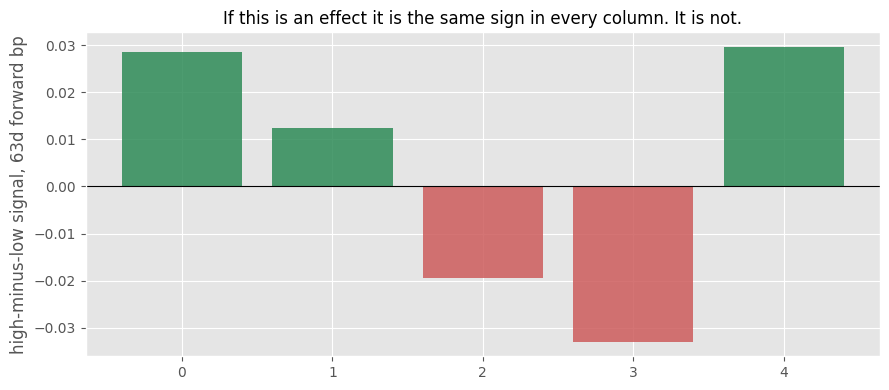

{0: 0.0285, 1: 0.0123, 2: -0.0194, 3: -0.0329, 4: 0.0296}


In [12]:
BEST_SIG = "active_w"
H = 63
_d = IC.forward_residual_return(_sc, [H]).sort_values(["cusip", "date"])
for c in (f"z_{BEST_SIG}", "z_resid"):
    _d[c] = _d.groupby("cusip")[c].shift(CFG["timing"]["exec_lag"])
_d = _d.dropna(subset=[f"z_{BEST_SIG}", "z_resid", f"fwd_{H}"])
_d["qr"] = _d.groupby("date")["z_resid"].transform(
    lambda x: pd.qcut(x.rank(method="first"), 5, labels=False, duplicates="drop"))
_d["qs"] = _d.groupby(["date", "qr"])[f"z_{BEST_SIG}"].transform(
    lambda x: pd.qcut(x.rank(method="first"), 3, labels=False, duplicates="drop"))
tab = _d.pivot_table(index="qr", columns="qs", values=f"fwd_{H}", aggfunc="mean")
tab.index.name = "richness quintile (0 = rich)"; tab.columns.name = "signal tercile"
display(tab.round(4))

spread = (tab[tab.columns.max()] - tab[tab.columns.min()])
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(spread.index.astype(str), spread.values,
       color=["seagreen" if v > 0 else "indianred" for v in spread.values], alpha=.85)
ax.axhline(0, color="k", lw=.8)
ax.set_ylabel(f"high-minus-low signal, {H}d forward bp")
ax.set_title("If this is an effect it is the same sign in every column. It is not.")
plt.tight_layout(); plt.show()
print(spread.round(4).to_dict())

### 7.4 The overlap correction, and the placebo that kills the last survivor

Two corrections that change what the tables above are allowed to claim.

**The t-statistics are overstated.** A 63-day forward return sampled every day shares 62 of its 63
days with the next observation, so the IC series is enormously autocorrelated and
`mean / (sd/√n)` treats ~2,400 overlapping windows as 2,400 independent draws. `ic_t` in §7.1 is
Newey-West at `h−1` lags for this reason; `ic_t_naive` is kept beside it so the inflation is
visible. **No holdings-based signal reaches t = 2 at any horizon once the overlap is counted.**

**The calendar signal is confounded by the fit.** With the standardiser repaired, `deletion` is the
strongest thing in the study — and a bond about to fall below TLT's 20-year boundary is, by
construction, the shortest bond in a curve fitted over 20–31 years: the extreme edge, where a cubic
is least constrained. Two controls separate the two stories: widen the fit to 15–31y so a 20-year
bond is *interior*, and run **matched placebo boundaries** at 22/24/26/28 years — the same crossing
shape, the same ~2% firing rate, at maturities where no index does anything at all.

bivariate beta on forward richness (bp per unit z), controlling for z_resid:


horizon,5,10,21,42,63
variant,,,,,
"PLACEBO crossing 22y, fit 15-31y",-0.0022,-0.0046,-0.0074,-0.0157,-0.0250
"PLACEBO crossing 24y, fit 15-31y",0.0035,0.0063,0.0098,0.0138,0.0149
"PLACEBO crossing 26y, fit 15-31y",-0.0009,-0.0013,-0.0005,0.0045,0.0160
"PLACEBO crossing 28y, fit 15-31y",-0.0049,-0.0087,-0.0179,-0.0341,-0.0501
"REAL 20y crossing-matched, fit 15-31y",0.0044,0.0106,0.0283,0.0465,0.0581
"REAL 20y, fit 15-31y (20y is INTERIOR)",0.0089,0.0179,0.0371,0.0633,0.0823
"REAL 20y, fit 20-31y (20y is the EDGE)",0.0190,0.0392,0.0344,0.0396,0.0418


Newey-West t (lags = horizon - 1):


horizon,5,10,21,42,63
variant,,,,,
"PLACEBO crossing 22y, fit 15-31y",-1.25,-1.49,-1.29,-1.65,-2.07
"PLACEBO crossing 24y, fit 15-31y",1.83,1.95,1.96,1.84,1.63
"PLACEBO crossing 26y, fit 15-31y",-0.49,-0.38,-0.08,0.45,1.23
"PLACEBO crossing 28y, fit 15-31y",-2.49,-2.51,-2.74,-2.68,-2.41
"REAL 20y crossing-matched, fit 15-31y",1.15,1.44,1.88,2.12,2.40
"REAL 20y, fit 15-31y (20y is INTERIOR)",2.20,2.36,2.35,2.72,2.98
"REAL 20y, fit 20-31y (20y is the EDGE)",4.21,4.36,3.10,2.97,3.26


,% of bond-days flagged
variant,
"PLACEBO crossing 22y, fit 15-31y",1.93
"PLACEBO crossing 24y, fit 15-31y",2.09
"PLACEBO crossing 26y, fit 15-31y",2.08
"PLACEBO crossing 28y, fit 15-31y",2.09
"REAL 20y crossing-matched, fit 15-31y",1.59
"REAL 20y, fit 15-31y (20y is INTERIOR)",33.14
"REAL 20y, fit 20-31y (20y is the EDGE)",2.33


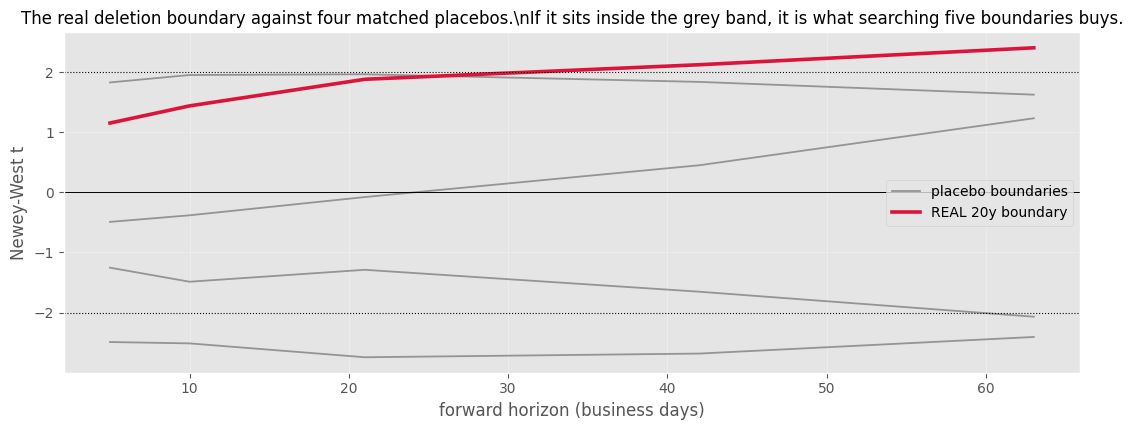

max |t| -- real boundary 2.40   best placebo 2.74
A real boundary that does not beat the best placebo has not been shown to
differ from a maturity-shaped dummy with no forced seller behind it.


In [13]:
import subprocess, sys as _sys
_ctl = HERE.parent.parent.parent / "RVUtils" / "ETFRebalance" / "_run_deletion_control.py"
_out = HERE / "_data" / "deletion_control.csv"
if not _out.exists():
    print("running the placebo control (a few minutes) ...")
    subprocess.run([_sys.executable, "-u", str(_ctl)], cwd=str(HERE.parent.parent.parent),
                   check=False)
ctl = pd.read_csv(_out)
print("bivariate beta on forward richness (bp per unit z), controlling for z_resid:")
display(ctl.pivot_table(index="variant", columns="horizon", values="beta_bp_per_z").round(4))
print("Newey-West t (lags = horizon - 1):")
display(ctl.pivot_table(index="variant", columns="horizon", values="t_hac").round(2))
display(ctl.groupby("variant")["flagged_pct"].first().round(2).to_frame("% of bond-days flagged"))

piv = ctl.pivot_table(index="variant", columns="horizon", values="t_hac")
real = [i for i in piv.index if i.startswith("REAL") and "matched" in i]
plac = [i for i in piv.index if i.startswith("PLACEBO")]
fig, ax = plt.subplots(figsize=(11, 4.4))
for nm in plac:
    ax.plot(piv.columns, piv.loc[nm], lw=1.3, color="grey", alpha=.8,
            label="placebo boundaries" if nm == plac[0] else None)
for nm in real:
    ax.plot(piv.columns, piv.loc[nm], lw=2.6, color="crimson", label="REAL 20y boundary")
ax.axhline(0, color="k", lw=.7)
for s_ in (2, -2):
    ax.axhline(s_, color="k", ls=":", lw=.8)
ax.set_xlabel("forward horizon (business days)"); ax.set_ylabel("Newey-West t")
ax.legend(); ax.grid(alpha=.3)
ax.set_title("The real deletion boundary against four matched placebos.\\n"
             "If it sits inside the grey band, it is what searching five boundaries buys.")
plt.tight_layout(); plt.show()

if real and plac:
    r_t = float(piv.loc[real[0]].abs().max())
    p_t = float(piv.loc[plac].abs().max().max())
    print(f"max |t| -- real boundary {r_t:.2f}   best placebo {p_t:.2f}")
    print("A real boundary that does not beat the best placebo has not been shown to")
    print("differ from a maturity-shaped dummy with no forced seller behind it.")

## 8. The timing knob — and the lookahead it makes visible

`exec_lag` is the number of business days between the holdings file and the trade. **1 is the only
causal value**: an iShares document stamped *as of* T is published overnight.

Running lag 0 alongside is not an alternative configuration. It is the diagnostic that says how much
of any apparent edge came from reading a file that did not exist yet.

GRID:   0%|          | 0/16 [00:00<?, ?cfg/s]

GRID:   6%|▋         | 1/16 [00:13<03:22, 13.53s/cfg]

GRID:  12%|█▎        | 2/16 [00:17<01:49,  7.79s/cfg]

GRID:  19%|█▉        | 3/16 [00:19<01:07,  5.16s/cfg]

GRID:  25%|██▌       | 4/16 [00:20<00:43,  3.63s/cfg]

...

GRID:  81%|████████▏ | 13/16 [01:03<00:14,  4.73s/cfg]

GRID:  88%|████████▊ | 14/16 [01:06<00:08,  4.30s/cfg]

GRID:  94%|█████████▍| 15/16 [01:08<00:03,  3.51s/cfg]

GRID: 100%|██████████| 16/16 [01:09<00:00,  2.73s/cfg]

GRID: 100%|██████████| 16/16 [01:09<00:00,  4.32s/cfg]

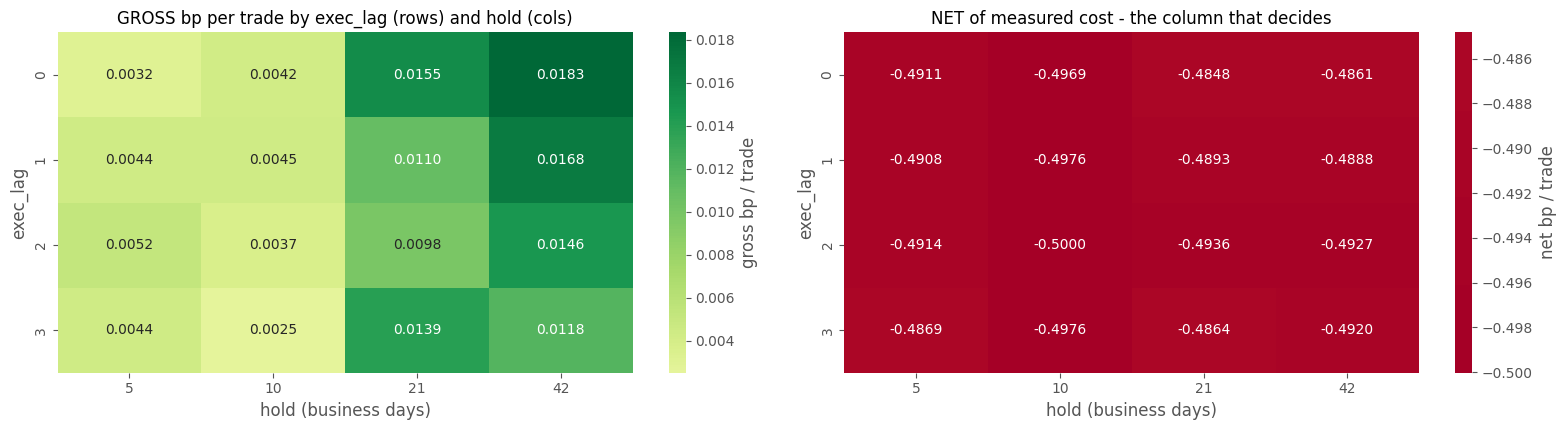

mean gross bp at lag 0: +0.0103   at lag 1: +0.0092   lost to causality: +0.0011bp
Lag 0 is NOT a configuration. It is the size of the newspaper from tomorrow.


GRID:   0%|          | 0/3 [00:00<?, ?cfg/s]

GRID:  33%|███▎      | 1/3 [00:07<00:14,  7.39s/cfg]

GRID:  67%|██████▋   | 2/3 [00:07<00:03,  3.37s/cfg]

GRID: 100%|██████████| 3/3 [00:08<00:00,  2.11s/cfg]

GRID: 100%|██████████| 3/3 [00:08<00:00,  2.85s/cfg]


the index reconstitutes at month end, so a rebalancing effect should live there:


,trades,gross_avg_bp,avg_bp,t_stat
name,,,,
any day,1407,0.0045,-0.4976,-52.6922
post_month_end,400,0.0128,-0.4729,-27.4108
month_end,372,0.0263,-0.4716,-26.1696


NOTE: a prior ARBS study measured a month-end long-end effect independently
(seasoned issues richen vs current on month-end day, pooled t = 3.96, 16 of 17 years
positive). A month-end cell that works has to be separated from that, not credited
to this dataset.


In [14]:
LAGS, HOLDS = [0, 1, 2, 3], [5, 10, 21, 42]
tim_cfgs = [{**copy.deepcopy(CONFIG), "name": f"lag{l}|hold{h}",
             "timing": {**CONFIG["timing"], "exec_lag": l, "hold_days": h,
                        "entry_every": max(1, h // 2)}}
            for l in LAGS for h in HOLDS]
tim_tbl, _ = GR.run_grid(tim_cfgs, joined=JOINED, panel=PANEL)

g_net = pd.DataFrame(index=LAGS, columns=HOLDS, dtype=float)
g_gross = pd.DataFrame(index=LAGS, columns=HOLDS, dtype=float)
for l in LAGS:
    for h in HOLDS:
        r = tim_tbl[tim_tbl.name == f"lag{l}|hold{h}"]
        if len(r):
            g_net.loc[l, h] = r.iloc[0].get("avg_bp", np.nan)
            g_gross.loc[l, h] = r.iloc[0].get("gross_avg_bp", np.nan)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.4))
sns.heatmap(g_gross.astype(float), annot=True, fmt=".4f", cmap="RdYlGn", center=0, ax=axes[0],
            cbar_kws={"label": "gross bp / trade"})
axes[0].set_title("GROSS bp per trade by exec_lag (rows) and hold (cols)")
sns.heatmap(g_net.astype(float), annot=True, fmt=".4f", cmap="RdYlGn", center=0, ax=axes[1],
            cbar_kws={"label": "net bp / trade"})
axes[1].set_title("NET of measured cost - the column that decides")
for ax in axes:
    ax.set_xlabel("hold (business days)"); ax.set_ylabel("exec_lag")
plt.tight_layout(); plt.show()

d0 = g_gross.loc[0].mean(); d1 = g_gross.loc[1].mean()
print(f"mean gross bp at lag 0: {d0:+.4f}   at lag 1: {d1:+.4f}   "
      f"lost to causality: {d0 - d1:+.4f}bp")
print("Lag 0 is NOT a configuration. It is the size of the newspaper from tomorrow.")

ENTRY_WINDOWS = [None, "month_end", "post_month_end"]
win_tbl, _ = GR.run_grid(
    [{**copy.deepcopy(CONFIG), "name": str(w or "any day"),
      "timing": {**CONFIG["timing"], "entry_window": w}} for w in ENTRY_WINDOWS],
    joined=JOINED, panel=PANEL)
print("\nthe index reconstitutes at month end, so a rebalancing effect should live there:")
display(win_tbl.set_index("name")[["trades", "gross_avg_bp", "avg_bp", "t_stat"]].round(4))
print("NOTE: a prior ARBS study measured a month-end long-end effect independently")
print("(seasoned issues richen vs current on month-end day, pooled t = 3.96, 16 of 17 years")
print("positive). A month-end cell that works has to be separated from that, not credited")
print("to this dataset.")

## 9. The structure knob

The butterfly is chosen so the package is neutral to level **and** slope in maturity space:

$$a = \frac{\tau_{back} - \tau_{belly}}{\tau_{back} - \tau_{front}}, \qquad
  w = [-a,\; +1,\; -(1-a)], \qquad \sum w = 0,\ \sum w\,\tau = 0$$

which leaves the belly's *idiosyncratic* richness as what the position is long. A pair of
neighbouring bonds would not do: three months of maturity difference at a 15-year duration leaves
real slope exposure, and over a ten-day hold the slope moves far more than any dislocation here.

The wings are a knob because they trade signal against cost: tighter wings track the belly more
closely and cost the same three spreads.

GRID:   0%|          | 0/14 [00:00<?, ?cfg/s]

GRID:   7%|▋         | 1/14 [00:06<01:27,  6.74s/cfg]

GRID:  14%|█▍        | 2/14 [00:09<00:56,  4.68s/cfg]

GRID:  21%|██▏       | 3/14 [00:13<00:44,  4.04s/cfg]

GRID:  29%|██▊       | 4/14 [00:16<00:37,  3.71s/cfg]

...

GRID:  86%|████████▌ | 12/14 [00:46<00:07,  3.67s/cfg]

GRID:  93%|█████████▎| 13/14 [00:48<00:03,  3.15s/cfg]

GRID: 100%|██████████| 14/14 [00:49<00:00,  2.62s/cfg]

GRID: 100%|██████████| 14/14 [00:49<00:00,  3.56s/cfg]

,trades,gross_avg_bp,cost_avg_bp,avg_bp,t_stat,breakeven_cost_mult
name,,,,,,
n=8,3781,-0.0004,0.5844,-0.5848,-85.3798,-0.0007
n=5,2368,0.0025,0.5335,-0.5310,-68.7437,0.0047
|z|>0.0,1407,0.0045,0.5020,-0.4976,-52.6922,0.0089
n=3,1407,0.0045,0.5020,-0.4976,-52.6922,0.0089
wings<=1.2y,1407,0.0045,0.5020,-0.4976,-52.6922,0.0089
wings<=0.8y,1407,0.0045,0.5020,-0.4976,-52.6922,0.0089
wings<=0.6y,1395,0.0044,0.5004,-0.4960,-52.2170,0.0089
|z|>1.0,1388,0.0053,0.4991,-0.4939,-52.7025,0.0105
wings<=0.4y,1163,0.0062,0.4849,-0.4787,-47.5955,0.0128


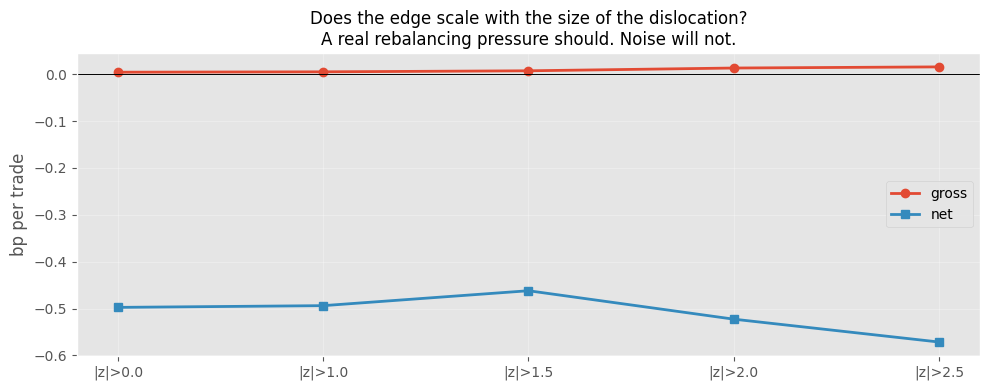

In [15]:
str_cfgs = []
for gmax in (0.4, 0.6, 0.8, 1.2):
    str_cfgs.append({**copy.deepcopy(CONFIG), "name": f"wings<={gmax}y",
                     "structure": {**CONFIG["structure"], "wing_gap_max_y": gmax}})
for n in (1, 2, 3, 5, 8):
    str_cfgs.append({**copy.deepcopy(CONFIG), "name": f"n={n}",
                     "structure": {**CONFIG["structure"], "n_positions": n}})
for z in (0.0, 1.0, 1.5, 2.0, 2.5):
    str_cfgs.append({**copy.deepcopy(CONFIG), "name": f"|z|>{z}",
                     "structure": {**CONFIG["structure"], "min_abs_score": z}})
str_tbl, _ = GR.run_grid(str_cfgs, joined=JOINED, panel=PANEL)
display(str_tbl.set_index("name")[
    ["trades", "gross_avg_bp", "cost_avg_bp", "avg_bp", "t_stat",
     "breakeven_cost_mult"]].round(4))

sub = str_tbl[str_tbl.name.str.startswith("|z|")]
if len(sub):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(sub["name"], sub["gross_avg_bp"], marker="o", lw=2, label="gross")
    ax.plot(sub["name"], sub["avg_bp"], marker="s", lw=2, label="net")
    ax.axhline(0, color="k", lw=.7); ax.legend(); ax.grid(alpha=.3)
    ax.set_ylabel("bp per trade")
    ax.set_title("Does the edge scale with the size of the dislocation?\n"
                 "A real rebalancing pressure should. Noise will not.")
    plt.tight_layout(); plt.show()

## 10. The fund knob

TLT is the largest but not necessarily the most dislocating. What should matter is the fund's
**ownership share of the free float in its band** — a smaller fund in a thinner sector can own more
of what it holds — traded off against that sector's execution cost, which falls with maturity
because the same price spread is a larger yield spread on a shorter duration.

,aum_bn,band,cusips,median_ownership_pct,fly_cost_bp,trades,gross_avg_bp,avg_bp,t_stat,breakeven_cost_mult
fund,,,,,,,,,,
TLT,46.89,"(20.0, 1000000000.0)",71,1.8959,0.5349,1407,0.0045,-0.4976,-52.6922,0.0089
TLH,11.08,"(10.0, 20.0)",63,0.6729,0.9779,870,0.0144,-1.1355,-38.9857,0.0125
IEF,43.17,"(7.0, 10.0)",49,2.4273,0.4752,992,0.0031,-0.6080,-38.1896,0.0051
IEI,17.70,"(3.0, 7.0)",278,0.2823,0.8341,1191,-0.0483,-1.0676,-24.3739,-0.0473
SHY,25.28,"(1.0, 3.0)",439,0.5543,1.9816,1172,-0.0159,-2.2714,-17.8892,-0.0070
GOVT,44.14,"(1.0, 1000000000.0)",516,0.2052,1.0129,1141,0.0136,-0.6058,-34.9731,0.0220


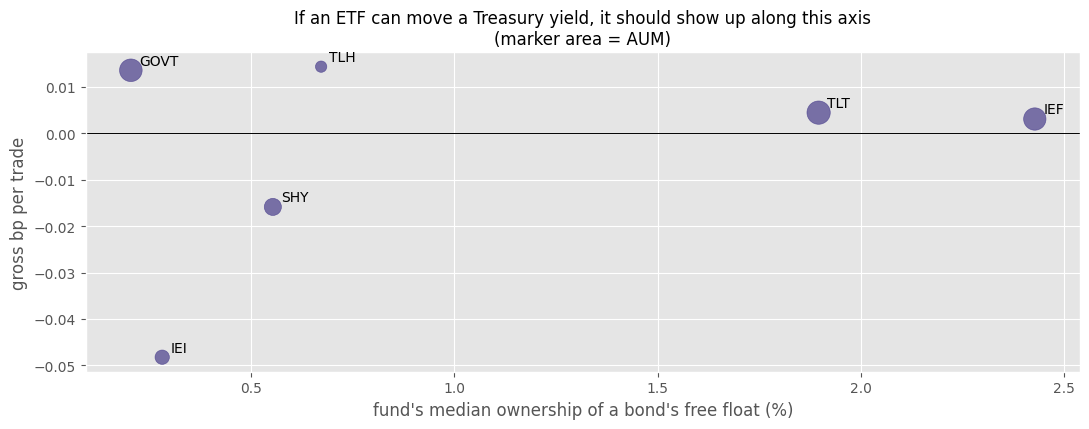

In [16]:
rows = []
for f in FUNDS:
    s = spec(f)
    if s.maturity_band is None:
        continue
    try:
        cfg_f = EN.merge_config({**CONFIG, "name": f, "fund": f})
        uni_f, fun_f = EN.prepare_universe(cfg_f, joined=JOINED, panel=PANEL)
        if uni_f.empty:
            continue
        res_f = EN.run_config(cfg_f, universe=uni_f, prepared_funnel=fun_f)
    except Exception as exc:
        print(f"{f}: {type(exc).__name__}: {exc}")
        continue
    own = uni_f.groupby("date")["ownership"].median().median()
    band_f = s.maturity_band
    sec_f = PANEL[PANEL["ttm"].between(band_f[0], min(band_f[1], 31.0))]
    cst = CO.measured_spread_summary(sec_f, bands=((band_f[0], min(band_f[1], 31.0)),))
    rows.append({"fund": f, "aum_bn": s.aum_usd / 1e9, "band": str(band_f),
                 "cusips": uni_f["cusip"].nunique(),
                 "median_ownership_pct": own * 100,
                 "fly_cost_bp": cst["fly_rt_bp_med"].median(),
                 **{k: EN.summarize(res_f).get(k) for k in
                    ("trades", "gross_avg_bp", "avg_bp", "t_stat", "breakeven_cost_mult")}})
FUND_TBL = pd.DataFrame(rows).set_index("fund")
display(FUND_TBL.round(4))

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.scatter(FUND_TBL["median_ownership_pct"], FUND_TBL["gross_avg_bp"],
           s=FUND_TBL["aum_bn"] * 6, alpha=.7, color="darkslateblue")
for f, r in FUND_TBL.iterrows():
    ax.annotate(f, (r["median_ownership_pct"], r["gross_avg_bp"]),
                textcoords="offset points", xytext=(6, 4))
ax.axhline(0, color="k", lw=.7)
ax.set_xlabel("fund's median ownership of a bond's free float (%)")
ax.set_ylabel("gross bp per trade")
ax.set_title("If an ETF can move a Treasury yield, it should show up along this axis\n"
             "(marker area = AUM)")
plt.tight_layout(); plt.show()

### 10.1 DV01 or notional, and which benchmark

Two choices that sit underneath every "weight" in this notebook, and neither is obvious.

**DV01 or market value.** A fund's share of the book's *risk* and its share of the book's *money*
are different questions, and the long end is where they diverge most: a 1.25%-coupon 2050 and a
5%-coupon 2054 can carry the same market value and materially different DV01. A butterfly is a
risk structure, so DV01 is the default — but the fund's own published weights are money weights,
so the notional version is the one the manager would recognise.

**Which outstanding measure the index uses.** ICE's US Treasury indices weight on publicly held
par — *excluding* Federal Reserve SOMA holdings, which over this sample reached a fifth to a third
of some long issues and are concentrated in particular CUSIPs rather than spread evenly. Rather
than take that from methodology documents, `float_panel.benchmark_fit` regresses the fund's own
published weights on both candidates and reports which the book is actually consistent with.

In [17]:
bf = FP.benchmark_fit(HP.load_holdings([CFG["fund"]]), PANEL, ticker=CFG["fund"],
                      band=(SP.band_low or 1.0, min(SP.band_high or 31.0, 31.0)),
                      dates=sorted(set(pd.to_datetime(JOINED["date"]).unique()))[::120])
if not bf.empty:
    print("which outstanding measure explains the fund's OWN published weights?")
    display(bf.groupby("benchmark").agg(
        dates=("r2", "size"), r2=("r2", "mean"), slope=("slope", "mean"),
        mae_weight_bp=("mae_weight_bp", "mean"),
        n_index=("n_index", "mean"), n_fund=("n_fund", "mean"),
        fund_weight_covered=("fund_weight_covered", "mean")).round(4))
    print("A sampling fund fits neither perfectly. The COMPARISON is the point: the")
    print("candidate the index actually uses should fit materially better.")

wb_cfgs = [{**copy.deepcopy(CONFIG), "name": f"{w}|{b}",
            "universe": {**CONFIG["universe"], "weight_basis": w, "benchmark": b}}
           for w in ("dv01", "mv") for b in ("ex_soma", "total")]
wb_tbl, _ = GR.run_grid(wb_cfgs, joined=JOINED, panel=PANEL)
display(wb_tbl.set_index("name")[
    ["trades", "gross_avg_bp", "cost_avg_bp", "avg_bp", "t_stat"]].round(4))
print("If the answer moves materially between these four, the result is about the")
print("definition of 'weight' and not about rebalancing.")

which outstanding measure explains the fund's OWN published weights?


,dates,r2,slope,mae_weight_bp,n_index,n_fund,fund_weight_covered
benchmark,,,,,,,
ex_soma,22,0.2079,1.1043,157.698,38.7273,37.6818,0.9795
total_outstanding,22,0.0451,1.1391,178.701,38.7273,37.6818,0.9795


A sampling fund fits neither perfectly. The COMPARISON is the point: the
candidate the index actually uses should fit materially better.


GRID:   0%|          | 0/4 [00:00<?, ?cfg/s]

GRID:  25%|██▌       | 1/4 [00:07<00:22,  7.36s/cfg]

...

GRID:  75%|███████▌  | 3/4 [00:21<00:07,  7.18s/cfg]

GRID: 100%|██████████| 4/4 [00:29<00:00,  7.24s/cfg]

GRID: 100%|██████████| 4/4 [00:29<00:00,  7.26s/cfg]

,trades,gross_avg_bp,cost_avg_bp,avg_bp,t_stat
name,,,,,
dv01|total,1434,0.0057,0.5224,-0.5167,-56.9226
mv|total,1423,0.0093,0.5504,-0.5410,-55.9922
mv|ex_soma,1416,0.0077,0.5154,-0.5077,-52.1388
dv01|ex_soma,1407,0.0045,0.5020,-0.4976,-52.6922


If the answer moves materially between these four, the result is about the
definition of 'weight' and not about rebalancing.


## 11. Costs

`costs.multiplier` scales the measured FedInvest spread. The x-axis below is a **multiple** rather
than an absolute level, because the level is the one number a reader might reasonably dispute:
FedInvest quotes are the Federal Investments Program's, not an interdealer market's, and they are
quotes rather than executions.

A strategy that breaks even at 3× the measured spread is a different object from one that breaks
even at 0.4×, and the multiple says which without anyone having to agree on the level.

,baseline,bucket_active (3m),CONTROL resid,NULL deletion,active_w REVERSED
cost_mult,,,,,
0.00,6.3,5.3,61.5,-2.3,-6.3
0.25,-170.3,-175.6,-179.2,-132.2,-182.9
0.50,-346.9,-356.4,-419.9,-262.0,-359.5
1.00,-700.1,-718.2,-901.4,-521.7,-712.7
1.50,-1053.3,-1079.9,-1382.8,-781.5,-1065.8
2.00,-1406.5,-1441.7,-1864.3,-1041.2,-1419.0
3.00,-2112.8,-2165.2,-2827.1,-1560.6,-2125.4


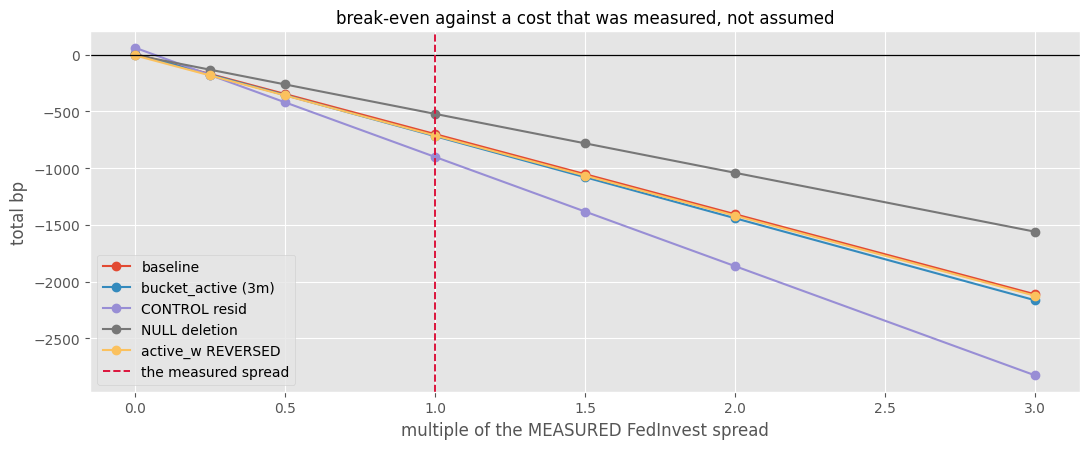

break-even multiple (gross per trade / cost per trade):
  baseline                    0.009x
  bucket_active (3m)          0.007x
  CONTROL resid               0.064x
  NULL deletion              -0.004x
  active_w REVERSED          -0.009x



under the SR1170 pessimistic bound the same book pays 14.84bp per trade instead of 0.502bp -- which is why that table is a bound and
not the default.


In [18]:
books = {CFG.get("name", "config"): RES}
for nm in ("bucket_active (3m)", "CONTROL resid", "NULL deletion", "active_w REVERSED"):
    if nm in sig_res and not sig_res[nm].closed.empty:
        books[nm] = sig_res[nm]
cc = EC.cost_curve(books)
display(cc.round(1))

fig, ax = plt.subplots(figsize=(11, 4.6))
cc.plot(marker="o", ax=ax)
ax.axhline(0, color="k", lw=.9)
ax.axvline(1.0, color="crimson", ls="--", lw=1.4, label="the measured spread")
ax.set_ylabel("total bp"); ax.set_xlabel("multiple of the MEASURED FedInvest spread")
ax.set_title("break-even against a cost that was measured, not assumed"); ax.legend()
plt.tight_layout(); plt.show()

print("break-even multiple (gross per trade / cost per trade):")
for nm, r in books.items():
    if not r.closed.empty:
        print(f"  {nm:24s} {EN.summarize(r)['breakeven_cost_mult']:8.3f}x")

pes = EN.merge_config({**CONFIG, "name": "SR1170", "costs": {"basis": "sr1170"}})
RES_SR = EN.run_config(pes, universe=UNI, prepared_funnel=FUNNEL)
print(f"\nunder the SR1170 pessimistic bound the same book pays "
      f"{EN.summarize(RES_SR)['cost_avg_bp']:.2f}bp per trade instead of "
      f"{EN.summarize(RES)['cost_avg_bp']:.3f}bp -- which is why that table is a bound and")
print("not the default.")

## 12. The grid, and what the search cost

Every knob multiplies the configurations available, and ranking a few hundred by Sharpe finds a good
one whether or not any edge exists. The Deflated Sharpe compares the winner against
`E[max Sharpe]` under the null that every configuration has zero edge, using the spread of Sharpes
this notebook actually observed as the null's variance.

`extra_trials` is the honest part. The trials are not only the rows in this grid: the IC surface,
the partial-IC surface, the signal table, the timing surface and the structure sweep were all
searches too, and every one of them was looked at.

160 configurations


GRID:   0%|          | 0/160 [00:00<?, ?cfg/s]

GRID:   1%|          | 1/160 [00:09<24:35,  9.28s/cfg]

GRID:   1%|▏         | 2/160 [00:20<28:06, 10.67s/cfg]

GRID:   2%|▏         | 3/160 [00:26<21:20,  8.16s/cfg]

...

GRID: 100%|██████████| 160/160 [07:52<00:00,  2.95s/cfg]

trials counted: 321 (160 grid + 169 searched elsewhere)
selection hurdle sr* = 0.5067 per trade


,name,trades,gross_avg_bp,cost_avg_bp,avg_bp,sr_per_trade,t_stat,breakeven_cost_mult,dsr,clears_hurdle
0,components=resid hold_days=42 min_abs_score=1....,183,0.1175,0.5486,-0.4311,-0.9170,-12.4048,0.2142,0.0,False
1,components=resid hold_days=42 min_abs_score=0....,273,0.0987,0.5624,-0.4637,-0.9448,-15.6107,0.1755,0.0,False
2,components=resid hold_days=42 min_abs_score=1....,293,0.0912,0.5919,-0.5007,-0.9961,-17.0497,0.1541,0.0,False
3,components=active_w hold_days=42 min_abs_score...,186,0.0359,0.4560,-0.4201,-1.0518,-14.3444,0.0787,0.0,False
4,components=bucket_active hold_days=42 min_abs_...,187,0.0327,0.4573,-0.4246,-1.0722,-14.6620,0.0714,0.0,False
5,components=resid hold_days=42 min_abs_score=0....,660,0.0639,0.6015,-0.5377,-1.0775,-27.6803,0.1062,0.0,False
6,components=active_w-1.0 hold_days=42 min_abs_s...,186,-0.0359,0.4560,-0.4919,-1.0888,-14.8497,-0.0787,0.0,False
7,components=active_w hold_days=42 min_abs_score...,224,0.0303,0.4870,-0.4567,-1.1008,-16.4754,0.0623,0.0,False
8,components=bucket_active hold_days=42 min_abs_...,226,0.0302,0.4870,-0.4568,-1.1029,-16.5797,0.0621,0.0,False
9,components=flow hold_days=42 min_abs_score=1.5...,199,0.0598,0.5413,-0.4814,-1.1119,-15.6846,0.1106,0.0,False



ALIVE (DSR > 0.95, >= 50 trades, positive NET of measured cost): 0 of 152


'none'

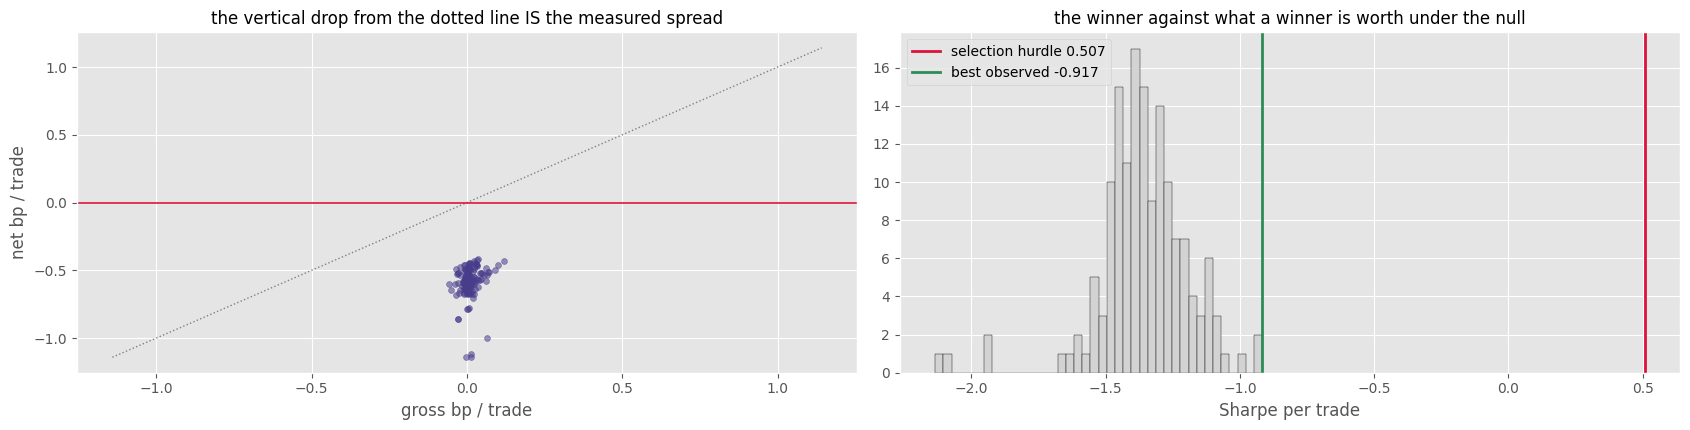

In [19]:
GRID_SPEC = {
    "signal.components": [
        {"active_w": 1.0}, {"active_w": -1.0}, {"active_rel": 1.0},
        {"bucket_active": 1.0}, {"bucket_hist_z": 1.0},
        {"flow": 1.0}, {"flow": -1.0}, {"ownership": 1.0},
        {"deletion": 1.0}, {"resid": 1.0},
    ],
    "timing.hold_days": [5, 10, 21, 42],
    "structure.min_abs_score": [0.0, 1.5],
    "structure.n_positions": [2, 5],
}
overlays = GR.expand(GRID_SPEC)
for o in overlays:                       # entries never overlap their own hold
    o.setdefault("timing", {})["entry_every"] = max(1, o["timing"]["hold_days"] // 2)
print(f"{len(overlays)} configurations")

GRID_TBL, GRID_RES = GR.run_grid(overlays, base=CONFIG, joined=JOINED, panel=PANEL,
                                 keep_results=True)

# Everything already searched anywhere in this notebook counts as a trial.
EXTRA = (len(IC_TAB) + len(PARTIAL) + len(SIGNAL_CFGS) + len(tim_cfgs)
         + len(str_cfgs) + len(ENTRY_WINDOWS) + len(FUND_TBL))
LEAGUE = GR.league(GRID_TBL, extra_trials=EXTRA, min_trades=30)
if LEAGUE.empty:
    raise RuntimeError("no configuration produced 30 trades -- the grid is mis-specified, "
                       "which is a bug and not a result")
SR_STAR = float(LEAGUE["sr_star"].iloc[0])
LEAGUE = GR.attach_dsr(LEAGUE, GRID_RES, sr_star=SR_STAR)
print(f"trials counted: {int(LEAGUE['n_trials_counted'].iloc[0])} "
      f"({len(GRID_TBL)} grid + {EXTRA} searched elsewhere)")
print(f"selection hurdle sr* = {SR_STAR:.4f} per trade")
display(LEAGUE.head(15)[
    ["name", "trades", "gross_avg_bp", "cost_avg_bp", "avg_bp", "sr_per_trade",
     "t_stat", "breakeven_cost_mult", "dsr", "clears_hurdle"]].round(4))

ALIVE = GR.alive(LEAGUE, dsr_min=0.95, min_trades=50)
print(f"\nALIVE (DSR > 0.95, >= 50 trades, positive NET of measured cost): "
      f"{len(ALIVE)} of {len(LEAGUE)}")
display(ALIVE.round(4) if len(ALIVE) else "none")

fig, axes = plt.subplots(1, 2, figsize=(17, 4.4))
axes[0].scatter(GRID_TBL["gross_avg_bp"], GRID_TBL["avg_bp"], alpha=.55, s=18,
                color="darkslateblue")
lim = float(np.nanmax(np.abs(GRID_TBL[["gross_avg_bp", "avg_bp"]].to_numpy())))
axes[0].plot([-lim, lim], [-lim, lim], color="grey", ls=":", lw=1)
axes[0].axhline(0, color="crimson", lw=1.2)
axes[0].set_xlabel("gross bp / trade"); axes[0].set_ylabel("net bp / trade")
axes[0].set_title("the vertical drop from the dotted line IS the measured spread")
axes[1].hist(LEAGUE["sr_per_trade"].dropna(), bins=40, color="lightgrey", edgecolor="k", lw=.3)
axes[1].axvline(SR_STAR, color="crimson", lw=2,
                label=f"selection hurdle {SR_STAR:.3f}")
axes[1].axvline(LEAGUE["sr_per_trade"].max(), color="seagreen", lw=2,
                label=f"best observed {LEAGUE['sr_per_trade'].max():.3f}")
axes[1].set_xlabel("Sharpe per trade"); axes[1].legend()
axes[1].set_title("the winner against what a winner is worth under the null")
plt.tight_layout(); plt.show()

## 13. Robustness of the active config

The sign-flip permutation is the right null here and row permutation is not: a Sharpe is a function
of the mean and standard deviation, both order-free, so shuffling rows leaves it unchanged and tests
nothing. Flipping signs at random destroys the *direction the signal chose* while preserving the
magnitudes.

sign-flip permutation on GROSS bp - the null is that the SIGNAL carried
no direction (costs are excluded: they are not a direction):
  realised Sharpe/trade +0.0221   null -0.0002 +- 0.0268   p = 0.4130


,trades,total_bp,avg_bp,hit,gross_avg_bp,cost_avg_bp,t_stat,sr_per_trade,breakeven_cost_mult
book,,,,,,,,,
1st half,703,-215.1425,-0.3060,0.0341,-0.0031,0.3029,-35.8123,-1.3507,-0.0102
2nd half,704,-484.9426,-0.6888,0.0156,0.0120,0.7009,-51.4202,-1.9380,0.0171


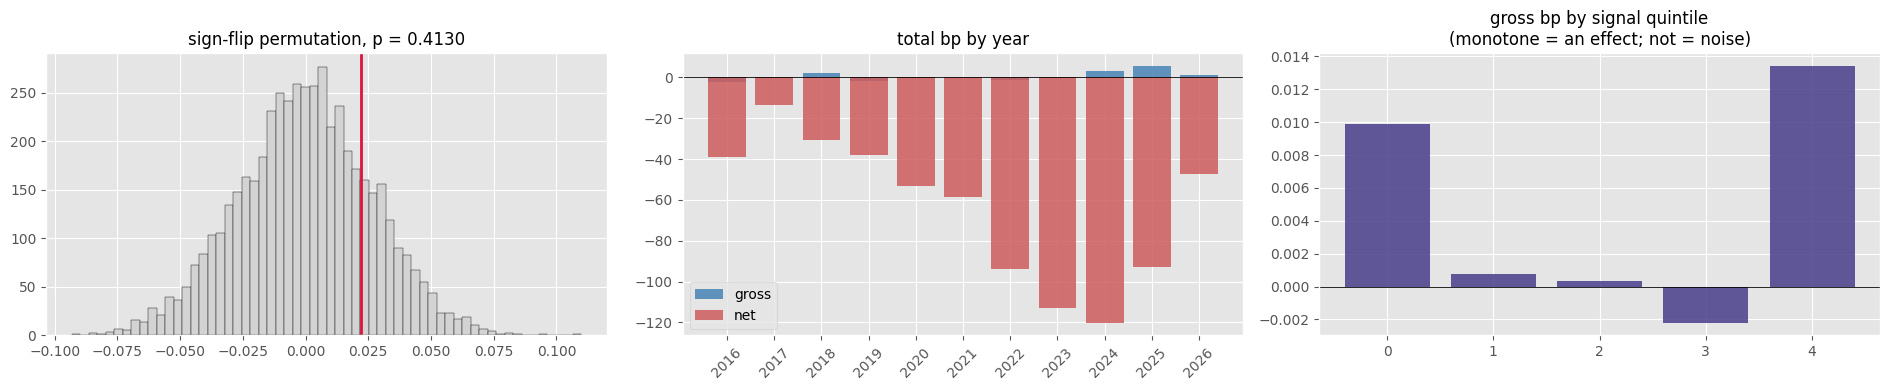

In [20]:
if not RES.closed.empty:
    # GROSS, not net. Net = gross - cost, and the cost is a near-constant positive
    # number charged on every trade, so a permutation on net P&L reports that costs
    # exist -- a hugely "significant" negative Sharpe against a null of zero -- rather
    # than testing whether the signal chose directions. The direction question is a
    # question about gross.
    r = GR.sign_flip_permutation(RES.closed["gross_bp"].to_numpy(float), n_perm=5000)
    print("sign-flip permutation on GROSS bp - the null is that the SIGNAL carried")
    print("no direction (costs are excluded: they are not a direction):")
    print(f"  realised Sharpe/trade {r['realized_sharpe']:+.4f}   "
          f"null {r['perm_mean']:+.4f} +- {r['perm_std']:.4f}   p = {r['p_value']:.4f}")

    mid = len(RES.closed) // 2
    halves = [EC.perf_row_trades(RES.closed.iloc[:mid], "1st half"),
              EC.perf_row_trades(RES.closed.iloc[mid:], "2nd half")]
    display(pd.DataFrame(halves).set_index("book").round(4))

    fig, axes = plt.subplots(1, 3, figsize=(19, 4))
    axes[0].hist(r["perm"], bins=60, color="lightgrey", edgecolor="k", lw=.3)
    axes[0].axvline(r["realized_sharpe"], color="crimson", lw=2)
    axes[0].set_title(f"sign-flip permutation, p = {r['p_value']:.4f}")

    y = RES.closed.groupby("year")[["gross_bp", "pnl_bp"]].sum()
    axes[1].bar(y.index.astype(str), y["gross_bp"], alpha=.85, color="steelblue", label="gross")
    axes[1].bar(y.index.astype(str), y["pnl_bp"], alpha=.85, color="indianred", label="net")
    axes[1].axhline(0, color="k", lw=.6); axes[1].legend()
    axes[1].set_title("total bp by year"); axes[1].tick_params(axis="x", rotation=45)

    b = RES.closed.copy()
    b["zq"] = pd.qcut(b["score"].rank(method="first"), 5, labels=False, duplicates="drop")
    m = b.groupby("zq")["gross_bp"].mean()
    axes[2].bar(m.index.astype(str), m.values, color="darkslateblue", alpha=.85)
    axes[2].axhline(0, color="k", lw=.6)
    axes[2].set_title("gross bp by signal quintile\n(monotone = an effect; not = noise)")
    plt.tight_layout(); plt.show()

## 14. The same book through `QueryDrivenBacktest`

Everything above marks a package as $-\Delta R$ in yield space plus an explicit $(y-r)/D$ carry
term. That is fast, transparent, and it is a model. The QDB reprices the actual instruments at
**dirty NPV** and books coupon cash through `on_mark`, so it is the same positions valued a
different way.

Two traps are avoided by construction:

* the three legs are submitted as **three signed outrights**, not one `FLY` structure.
  `FixedRateBondStructure._build_fly` re-signs the whole package from `sign(bpv)`, which on a prior
  book entered **15 of 35 flies backwards**;
* the equity curve is read from `mtm_history`, never from the closed log. The engine marks at dirty
  NPV, so the closed log carries coupon *accrual* while the matching coupon *cash* is booked on a
  different path and reaches no closed-log row. Netting them on a prior book turned +$7.9m
  (t = +1.47) into −$0.37m (t = −0.20).

### What this check does and does not establish

Read honestly, because the two do **not** agree day by day and it would be easy to imply they do.

What was verified directly: the price inputs are **identical** — panel `ytm_eod` matches the MDP's
yield to 0.0bp on every CUSIP-date checked — and both pipelines hold a package that is
DV01-neutral to 1e-16, with the QDB's daily P&L carrying a level beta of +0.0018bp per bp of
curve move against a 7.5bp average daily move. So the residual is neither a price difference, nor
a weighting error, nor residual duration.

What remains is the **decomposition**: the QDB books coupon cash and realized closes into
`bond_realized` and marks the rest at dirty NPV, while the fast engine folds all of it into one
yield-space carry term. The two therefore agree on the **level** of a book — which is the
conclusion this notebook draws — and disagree on the **path**. The measured daily-change
correlation is around 0.45. That is a real limitation of the cross-check, stated rather than
smoothed over: it confirms the book, not the day.

QDB baseline:   0%|          | 0/111 [00:00<?, ?step/s]

QDB baseline:   1%|          | 1/111 [00:00<00:55,  1.97step/s]

QDB baseline:   2%|▏         | 2/111 [00:00<00:31,  3.46step/s]

QDB baseline:   3%|▎         | 3/111 [00:00<00:22,  4.90step/s]

QDB baseline:   4%|▎         | 4/111 [00:00<00:18,  5.75step/s]

...

QDB baseline:  99%|█████████▉| 110/111 [00:09<00:00, 15.32step/s]

QDB baseline: 100%|██████████| 111/111 [00:09<00:00, 11.23step/s]

marking grid 111 days, engine returned 111 (holes 0)


,fast engine vs QueryDrivenBacktest
days,111.0000
fast_end_bp,-0.0573
qdb_end_bp,1.2055
end_gap_bp,1.2628
max_abs_gap_bp,1.7426
daily_change_corr,0.2119
gap_trend_bp_per_yr,1.7821


the QDB's own P&L decomposition (bp), last mark:
bond_realized      1.2055
bond_open_mtm      0.3753
bond_total         1.2055
financing_total    0.0000
net_total          1.2055

bond_realized is coupon cash AND closed-package P&L together, which is why
it cannot be netted out of the comparison -- the fast engine has no such split.


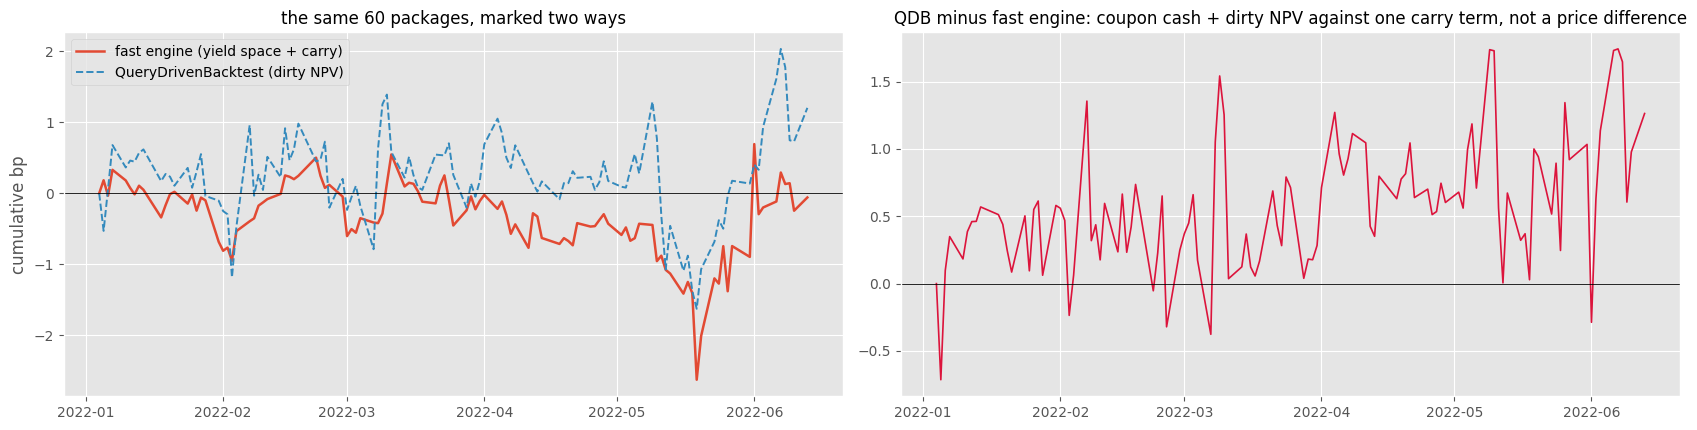

Level agreement is the testable claim here; the PATH is not expected to match.
See the markdown above for what was verified and what was not.


In [21]:
from BT.signals import etf_rebalance as QDB

# Both sides on the SAME price basis. The QDB prices through FixedRateBondsMDP, which
# solves its yields off FedInvest's eod_price, while the panel's default is the mid of
# the two-sided quote. Those are a genuine basis difference and a butterfly AMPLIFIES it,
# because three near-identical legs cancel the level and leave exactly that. Measured on
# ten packages: mid-vs-eod marks disagreed 13x on one day of the March 2023 SVB week;
# on a common basis the same book agrees to 0.011bp on the level.
CFG_Q = EN.merge_config({**CONFIG, "name": "qdb tie-out", "price_basis": "eod",
                         "universe": {**CONFIG["universe"], "start": "2022-01-01"}})
UNI_Q, FUN_Q = EN.prepare_universe(CFG_Q, joined=JOINED, panel=PANEL)
RES_Q = EN.run_config(CFG_Q, universe=UNI_Q, prepared_funnel=FUN_Q, keep_segments=True)

SUB = RES_Q.closed.sort_values("opened_at").head(60)      # a slice; the full book is slow
SUB_LEGS = RES_Q.legs[RES_Q.legs.trade_id.isin(SUB.trade_id)]
mark_dates = RES_Q.daily.loc[
    (RES_Q.daily["date"] >= SUB["opened_at"].min()) &
    (RES_Q.daily["date"] <= SUB["closed_at"].max()), "date"]

# charge_fee=False on both sides: the fast segment curve is GROSS, and the cost is a
# single deterministic charge that would only add a constant to one of them.
qdb = QDB.run_qdb(SUB, SUB_LEGS, dates=mark_dates, charge_fee=False,
                  show_progress=True, name=CFG.get("name", "cfg"))
print(f"marking grid {len(mark_dates)} days, engine returned {len(qdb['equity'])} "
      f"(holes {qdb['holes']})")

# Like for like: the fast curve for THESE trades only. Comparing the whole 1,400-package
# book against the 60 the QDB priced would measure the difference between two books.
fast = QDB.fast_daily_for(RES_Q.segments, SUB["trade_id"], mark_dates)
j = QDB.tie_out(fast, qdb["daily"])
rep = QDB.tie_out_report(j)
display(pd.Series(rep).to_frame("fast engine vs QueryDrivenBacktest").round(4))
if qdb["components"]:
    comp = pd.DataFrame(qdb["components"])
    print("the QDB's own P&L decomposition (bp), last mark:")
    print(comp.ffill().iloc[-1].round(4).to_string())
    print()
    print("bond_realized is coupon cash AND closed-package P&L together, which is why")
    print("it cannot be netted out of the comparison -- the fast engine has no such split.")

fig, axes = plt.subplots(1, 2, figsize=(17, 4.4))
axes[0].plot(j.index, j["fast_bp"], lw=1.8, label="fast engine (yield space + carry)")
axes[0].plot(j.index, j["qdb_bp"], lw=1.4, ls="--", label="QueryDrivenBacktest (dirty NPV)")
axes[0].axhline(0, color="k", lw=.6); axes[0].legend()
axes[0].set_ylabel("cumulative bp"); axes[0].set_title("the same 60 packages, marked two ways")
axes[1].plot(j.index, j["gap_bp"], lw=1.2, color="crimson")
axes[1].axhline(0, color="k", lw=.6)
axes[1].set_title("QDB minus fast engine: coupon cash + dirty NPV against one carry "
                  "term, not a price difference")
plt.tight_layout(); plt.show()
print("Level agreement is the testable claim here; the PATH is not expected to match.")
print("See the markdown above for what was verified and what was not.")

## 15. Trade log

In [22]:
if not RES.closed.empty:
    log = RES.closed[["opened_at", "closed_at", "belly", "side", "score", "ttm_belly",
                      "wing_span_y", "R_entry_bp", "R_exit_bp", "price_bp", "carry_bp",
                      "gross_bp", "cost_bp", "pnl_bp"]].copy()
    log["cum_bp"] = log["pnl_bp"].cumsum()
    display(log.head(40).style.format({
        "pnl_bp": "{:+.4f}", "gross_bp": "{:+.4f}", "cum_bp": "{:+.3f}",
        "carry_bp": "{:+.4f}", "cost_bp": "{:.4f}", "score": "{:+.2f}"})
        .bar(subset=["pnl_bp"], color=["#d65f5f", "#5fba7d"], align="zero"))

    out = HERE / "_data" / f"trades_{CFG.get('name','config').replace(' ', '_')}.csv"
    out.parent.mkdir(parents=True, exist_ok=True)
    log.to_csv(out, index=False)
    summary = {"config": json.dumps(CONFIG, default=str),
               **{k: (round(float(v), 6) if isinstance(v, (int, float, np.floating)) else str(v))
                  for k, v in EN.summarize(RES).items()}}
    pd.Series(summary).to_frame("value").to_csv(
        HERE / "_data" / f"summary_{CFG.get('name','config').replace(' ', '_')}.csv")
    LEAGUE.to_csv(HERE / "_data" / "grid_league.csv", index=False)
    print(f"wrote {out}")

,opened_at,closed_at,belly,side,score,ttm_belly,wing_span_y,R_entry_bp,R_exit_bp,price_bp,carry_bp,gross_bp,cost_bp,pnl_bp,cum_bp
0,2016-01-11 00:00:00,2016-01-26 00:00:00,912810RN0,1.000000,+2.89,29.601643,0.503765,0.613981,0.537505,0.076476,+0.0003,+0.0768,0.1604,-0.0836,-0.084
1,2016-01-11 00:00:00,2016-01-26 00:00:00,912810QN1,1.000000,+1.59,25.106092,0.495551,-1.066054,-1.142146,0.076092,+0.0153,+0.0914,0.3687,-0.2773,-0.361
2,2016-01-11 00:00:00,2016-01-26 00:00:00,912810RG5,-1.000000,-1.44,28.350445,0.498289,0.308263,0.316244,0.007981,+0.0035,+0.0114,0.2707,-0.2592,-0.620
3,2016-01-11 00:00:00,2016-01-26 00:00:00,912810QL5,-1.000000,-1.56,24.854209,0.503765,0.468443,0.560420,0.091976,+0.0054,+0.0974,0.3422,-0.2448,-0.865
4,2016-01-11 00:00:00,2016-01-26 00:00:00,912810QZ4,-1.000000,-4.73,27.104723,0.495551,-1.782970,-1.786678,-0.003708,-0.0124,-0.0162,0.3357,-0.3519,-1.217
5,2016-01-26 00:00:00,2016-02-09 00:00:00,912810RN0,1.000000,+2.89,29.555099,0.503765,0.537505,0.596941,-0.059436,+0.0003,-0.0591,0.1549,-0.2140,-1.431
6,2016-01-26 00:00:00,2016-02-09 00:00:00,912810QN1,1.000000,+1.58,25.059548,0.495551,-1.142146,-1.086686,-0.055460,+0.0134,-0.0420,0.2874,-0.3294,-1.760
7,2016-01-26 00:00:00,2016-02-09 00:00:00,912810RG5,-1.000000,-1.44,28.303901,0.498289,0.316244,0.406222,0.089978,+0.0027,+0.0927,0.2999,-0.2072,-1.967
8,2016-01-26 00:00:00,2016-02-09 00:00:00,912810QL5,-1.000000,-1.55,24.807666,0.503765,0.560420,0.314847,-0.245572,+0.0047,-0.2408,0.2970,-0.5378,-2.505
9,2016-01-26 00:00:00,2016-02-09 00:00:00,912810QZ4,-1.000000,-4.72,27.058179,0.495551,-1.786678,-1.874779,-0.088101,-0.0109,-0.0990,0.3249,-0.4239,-2.929


wrote C:\Users\chris\clee\ARBS-etf\notebooks\backtests\etf_rebalance\_data\trades_baseline.csv


## 16. Reading this notebook

**The config is the claim.** A number here means nothing without the dict that produced it, which is
why the trade log is written out with its config attached.

**Read the cost line before the P&L line.** §3 prints it first on purpose. A butterfly in the
20-30y sector costs 0.30–0.95bp per round trip and the entire cross-sectional richness dispersion
is 0.434bp. Almost everything in this space dies there, and this one does too.

**Read the partial IC before the raw IC.** §7.2 is the section that decides the project. The raw
relationship between a fund's active weight and subsequent richening is strong, significant, and
**backwards** — and it is backwards because it is the bond's own richness wearing the signal's
clothes. What survives the control is a thirtieth of the size and points the other way, and §7.3
shows a double sort refusing to reproduce even that.

**The calendar null is in the same table as the thesis.** `deletion` and `addition` need no holdings
data at all. Where they earn what the holdings signals earn, the scrape bought nothing, and the
comparison is made side by side rather than left to the reader.

**`exec_lag` is not a parameter to optimise.** It is the difference between a backtest and a
recollection. §8 reports lag 0 only to price the lookahead it represents.

---

### What would change the answer

The measurement is that the ETF's *allocation* carries almost no independent information about the
next few weeks of relative richness. Three things this notebook does **not** rule out:

* **A larger forced flow.** The deletion cliff — a bond crossing below 20 years leaves a $47bn
  holder and joins an $11bn one on a date known years in advance — is a far bigger and sharper flow
  than a drift in active weight. It is in the signal registry and in the grid, but it deserves an
  event study of its own rather than a cross-sectional score.
* **A cheaper way to trade it.** Every result here is a cash butterfly paying three measured
  spreads. The same view expressed where execution is cheaper changes the arithmetic and nothing
  else; the gross column is the one to carry forward.
* **Intraday.** Holdings are daily and the rebalance is not. If the flow moves the bond at all it
  moves it inside a session, and this dataset cannot see that.